# Mesa Beaver Canal Simulation - Water-Greedy Stigmergy + Hemisphere Erosion

**UPDATED5** : Hemisphere erosion pipeline integrated.

### Per-year pipeline:
1. Mesa runs agents on current surface Ã¢â€ â€™ agents excavate
2. New excavation accumulated into cumulative counter_dem
3. `site_counter_dem_(year).csv` Ã¢â‚¬â€ cumulative excavation counts
4. `site_volume_(year).csv` Ã¢â‚¬â€ counts Ã¢â€ â€™ hemisphere radii (saturating at r_limit)
5. `2d_erosion_(year).csv` Ã¢â‚¬â€ hemispheres carved into ORIGINAL DEM (summed overlaps)
6. Hydrology recalculated on 2d_erosion surface via Landlab
7. Updated DEM + hydrology passed to agents for next year

**Key design:** Original DEM is immutable. Any year's surface can be reconstructed from original DEM + that year's counter_dem.

## Cell 1 -  Simulation Parameters

In [1]:
# ========================================
# SIMULATION PARAMETERS
# ========================================
from pathlib import Path
import csv
import re

# --- Input/Output ---
CSV_PATH = r"C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\RumneyRanch_slopes.csv"
CSV_DIR = Path(CSV_PATH).parent
SITE_NAME = Path(CSV_PATH).stem.removesuffix("_slopes")
SITE_SUMMARY_CSV = CSV_DIR / f"{SITE_NAME}_site_dem_summary.csv"

def _read_epsg_from_site_summary(summary_csv: Path, parameter_name: str = "DEM CRS") -> int:
    if not summary_csv.exists():
        raise FileNotFoundError(f"Site summary CSV not found: {summary_csv}")

    with open(summary_csv, newline="", encoding="utf-8-sig") as fh:
        rows = {
            row.get("Parameter", "").strip(): row.get("Value", "").strip()
            for row in csv.DictReader(fh)
        }

    raw_value = rows.get(parameter_name, "")
    if not raw_value:
        raise KeyError(
            f"Parameter '{parameter_name}' was not found in {summary_csv.name}"
        )

    match = re.search(r"(?:EPSG\s*:\s*)?(\d+)", raw_value)
    if not match:
        raise ValueError(
            f"Could not parse an EPSG code from '{parameter_name}={raw_value}' in {summary_csv.name}"
        )

    return int(match.group(1))

# Base directory where each *run folder* will be created.
RUNS_BASE_DIR = str(CSV_DIR / "runs")

# Pull projected CRS (meters) from the associated site summary CSV.
DATA_EPSG = _read_epsg_from_site_summary(SITE_SUMMARY_CSV)
print(f"Loaded DATA_EPSG={DATA_EPSG} from {SITE_SUMMARY_CSV.name}")

# Optional: if you know your DEM pixel size in meters, set it here; otherwise inferred.
GRID_SPACING_M = None  # e.g., 1.0

# --- Chunked deployment ---
RUN_BY_CHUNK = True
CHUNK_COL = "tile_id"  # deployment chunk identifier
CHUNK_SIZE_M = 100.0  # regenerate 100 m x 100 m chunk ids when tile metadata is absent
CHUNK_BUFFER_M = 25.0  # halo around each core tile so agents can move beyond artificial chunk edges
CHUNK_PREVIEW_ID = None  # Set to a specific chunk value for the downstream preview plots

# --- Temporal ---
N_YEARS = 2
TICKS_PER_YEAR = 365

# --- Agents ---
N_AGENTS = 5
VISION_MIN = 1
VISION_MAX = 4
AGENT_SPEED = 3
AGENT_START_MODE = "percentile_band"
AGENT_START_PERCENTILE_RANGE = (97.0, 99.0)  # local drainage-percentile band per chunk

# --- Excavation ---
EXCAVATION_DEPTH_M = 0.05

# --- Water recession ---
RECESSION_RATE = 1.0  # lower (0.1-1.0) => slower recession
RECESSION_NOISE_STD = 0.010  # Gaussian noise added to recession progress (0 disables)
WET_INFLUENCE_MAX_RADIUS = 1.5  # max wetting radius (cells) for high-drainage water sources

# --- Hemisphere Erosion ---
R_LIMIT = 0.75  # asymptotic max canal half-width (meters), from field data
# Set to ~50% of measured stream half-width at your site:
#   Acadia (stream 2.5-3m):   R_LIMIT = 0.75
#   Larger site (stream 5-6m): R_LIMIT = 1.5
#   No saturation:             R_LIMIT = None

# --- Debug / visualization ---
TRACK_MOVEMENT = True
PLOT_END_OF_YEAR = True

# --- Optional animation (can be data intensive) ---
SAVE_ANIMATION = False
ANIMATION_FRAME_EVERY_N_TICKS = 10
ANIMATION_FRAME_DURATION_MS = 120
KEEP_ANIMATION_FRAMES = False

Loaded DATA_EPSG=26912 from RumneyRanch_site_dem_summary.csv


## Cell 2 - Imports

In [2]:
# Core scientific computing
import numpy as np
import pandas as pd
import random
import math
import os
import json
import re

# Visualization
import matplotlib.pyplot as plt

# Animation (optional)
import imageio

# File management
from pathlib import Path

# Agent-based modeling
from mesa import Agent, Model

# Hydrology (Landlab yearly recompute)
from pyproj import Transformer
from landlab import RasterModelGrid
from landlab.components.flow_accum import FlowAccumulator
from landlab.components.lake_fill import LakeMapperBarnes

## Cell 3 - Utility Functions

In [3]:
def infer_step(vals):
    u = np.unique(np.round(np.asarray(vals, dtype=float), 6))
    u.sort()
    d = np.diff(u)
    d = d[d > 0]
    if d.size == 0:
        return np.nan
    r = np.round(d, 6)
    uniq, cnt = np.unique(r, return_counts=True)
    return float(uniq[np.argmax(cnt)])


def create_grid_FIXED(
    df: pd.DataFrame,
    grid_spacing: float = 1.0,
    x_col: str = "x",
    y_col: str = "y",
    value_cols=("elevation",),
    agg: str = "first",
    return_df_with_indices: bool = True
):
    if df.empty:
        raise ValueError("Input DataFrame is empty.")
    def _snap(v, s):
        return np.round(np.asarray(v, dtype=float) / s) * s
    x_snap = _snap(df[x_col].values, grid_spacing)
    y_snap = _snap(df[y_col].values, grid_spacing)
    x_coords = np.unique(x_snap)
    y_coords = np.unique(y_snap)
    nx, ny = len(x_coords), len(y_coords)
    x_to_ix = {x: i for i, x in enumerate(x_coords)}
    y_to_iy = {y: i for i, y in enumerate(y_coords)}
    grid = {
        "x_coords": x_coords,
        "y_coords": y_coords,
        "x_to_ix": x_to_ix,
        "y_to_iy": y_to_iy,
    }
    X, Y = np.meshgrid(x_coords, y_coords)
    grid["X"], grid["Y"] = X, Y
    work = df.copy()
    work["_x_snap"] = x_snap
    work["_y_snap"] = y_snap
    for col in value_cols:
        if col not in work.columns:
            grid[col] = np.full((ny, nx), np.nan, dtype=float)
            continue
        pv = (
            work.pivot_table(
                index="_y_snap",
                columns="_x_snap",
                values=col,
                aggfunc=agg,
                dropna=False,
            )
            .reindex(index=y_coords, columns=x_coords)
        )
        grid[col] = pv.values
    cand_cols = [c for c in value_cols if np.issubdtype(np.asarray(grid[c]).dtype, np.number)]
    if not cand_cols:
        presence = ~pd.isna(
            work.pivot_table(index="_y_snap", columns="_x_snap", values=value_cols[0], aggfunc="first")
             .reindex(index=y_coords, columns=x_coords)
             .values
        )
    else:
        stacks = [np.asarray(grid[c]) for c in cand_cols]
        presence = np.any(~np.isnan(stacks), axis=0) if len(stacks) > 1 else ~np.isnan(stacks[0])
    grid["mask"] = presence
    if return_df_with_indices:
        work["ix"] = [x_to_ix[x] for x in work["_x_snap"]]
        work["iy"] = [y_to_iy[y] for y in work["_y_snap"]]
        return grid, work.drop(columns=["_x_snap", "_y_snap"])
    return grid

## Cell 4 - Hydrology Recompute (Landlab)

In [4]:
def recompute_hydro_fields_landlab(
    df_in: pd.DataFrame,
    data_epsg: int,
    grid_spacing_m: float | None = None,
    agg: str = "mean",
    width_depth_fn=None,
) -> pd.DataFrame:
    """
    Recompute drainage area and slope from the current elevation field using Landlab.

    Expected input columns:
        x, y, elevation

    Optional downstream columns updated if present or produced:
        drainage_area_m2, slope, percentile, slope_degrees, width_m, depth_m

    Notes
    -----
    - If x/y appear to be lon/lat, they are projected to data_epsg.
    - Nodata cells are closed in the RasterModelGrid.
    - All grid edges are closed first, then exactly one valid perimeter outlet
      (the lowest valid boundary node) is reopened.
    - LakeMapperBarnes is used first to robustly fill and reroute large lakes.
    - If Barnes filling fails, the function falls back to DepressionFinderAndRouter,
      and finally to plain D8 flow accumulation.
    """
    df_out = df_in.copy()

    # ------------------------------------------------------------------
    # Validate required inputs
    # ------------------------------------------------------------------
    required = ["x", "y", "elevation"]
    for c in required:
        if c not in df_out.columns:
            raise ValueError(f"Missing required column: {c}")
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    df_valid = df_out.dropna(subset=required).copy()
    if df_valid.empty:
        raise ValueError("No valid rows with numeric x, y, and elevation.")

    # ------------------------------------------------------------------
    # Project lon/lat to the working CRS if needed
    # ------------------------------------------------------------------
    xmn, xmx = float(df_valid["x"].min()), float(df_valid["x"].max())
    ymn, ymx = float(df_valid["y"].min()), float(df_valid["y"].max())
    is_lonlat = (abs(xmn) <= 180 and abs(xmx) <= 180 and abs(ymn) <= 90 and abs(ymx) <= 90)

    if is_lonlat:
        tf = Transformer.from_crs("EPSG:4326", f"EPSG:{data_epsg}", always_xy=True)
        X, Y = tf.transform(df_valid["x"].to_numpy(), df_valid["y"].to_numpy())
        df_valid["x"] = X
        df_valid["y"] = Y
        df_out.loc[df_valid.index, "x"] = X
        df_out.loc[df_valid.index, "y"] = Y

    # ------------------------------------------------------------------
    # Infer grid spacing if not provided
    # ------------------------------------------------------------------
    if grid_spacing_m is None:
        dx_x = infer_step(df_valid["x"].values)
        dx_y = infer_step(df_valid["y"].values)
        grid_spacing_m = np.nanmin([dx_x, dx_y])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0

    # ------------------------------------------------------------------
    # Build regular grid from point dataframe
    # ------------------------------------------------------------------
    grid_dict, df_ixiy = create_grid_FIXED(
        df_valid,
        grid_spacing=grid_spacing_m,
        value_cols=("elevation",),
        agg=agg,
        return_df_with_indices=True,
    )

    x_coords = grid_dict["x_coords"]
    y_coords = grid_dict["y_coords"]
    nrows, ncols = len(y_coords), len(x_coords)

    try:
        mg = RasterModelGrid((nrows, ncols), xy_spacing=grid_spacing_m)
    except TypeError:
        mg = RasterModelGrid((nrows, ncols), grid_spacing_m)

    # ------------------------------------------------------------------
    # Prepare elevation raster
    # ------------------------------------------------------------------
    Z2d = np.array(grid_dict["elevation"], dtype=float, copy=True, order="C")

    valid_mask_2d = np.isfinite(Z2d)
    valid_mask_1d = valid_mask_2d.ravel(order="C")

    if not np.any(valid_mask_2d):
        raise ValueError("Elevation grid contains no finite values.")

    # Fill invalid cells only for storage / gradient calculation.
    # They will still be closed in the Landlab grid.
    safe_min = np.nanmin(Z2d[valid_mask_2d])
    Z2d_filled = np.where(valid_mask_2d, Z2d, safe_min).astype(float, copy=False)
    z_nodes = Z2d_filled.ravel(order="C").copy()

    mg.add_field("topographic__elevation", z_nodes, at="node", clobber=True)

    # ------------------------------------------------------------------
    # Boundary handling
    # ------------------------------------------------------------------
    # Close all edges first; then reopen exactly one valid outlet.
    mg.set_closed_boundaries_at_grid_edges(True, True, True, True)

    # Close all invalid/nodata cells anywhere in the grid
    mg.status_at_node[~valid_mask_1d] = mg.BC_NODE_IS_CLOSED

    # Choose the lowest valid perimeter node as the outlet
    perimeter = mg.boundary_nodes
    perimeter_valid = perimeter[valid_mask_1d[perimeter]]

    if perimeter_valid.size == 0:
        raise ValueError("No valid perimeter cells available for outlet selection.")

    outlet = int(perimeter_valid[np.argmin(z_nodes[perimeter_valid])])
    mg.status_at_node[outlet] = mg.BC_NODE_IS_FIXED_VALUE

    # ------------------------------------------------------------------
    # Flow routing
    # ------------------------------------------------------------------
    try:
        # Seed Landlab's flow fields, then use Barnes lake filling on a
        # separate surface to avoid outlet-search failures on large flats.
        fa = FlowAccumulator(mg, flow_director="D8")
        fa.run_one_step()

        mg.add_field("filled__elevation", z_nodes.copy(), at="node", clobber=True)
        lmb = LakeMapperBarnes(
            mg,
            method="D8",
            fill_flat=False,
            surface="topographic__elevation",
            fill_surface="filled__elevation",
            redirect_flow_steepest_descent=True,
            reaccumulate_flow=True,
            track_lakes=True,
            ignore_overfill=True,
        )
        lmb.run_one_step()
    except Exception as e:
        print(f"[hydro warning] Barnes lake routing failed: {type(e).__name__}: {e}")
        try:
            fa = FlowAccumulator(
                mg,
                surface="topographic__elevation",
                flow_director="D8",
                depression_finder="DepressionFinderAndRouter",
            )
            fa.run_one_step()
        except Exception as inner_e:
            print(f"[hydro warning] Depression routing failed: {type(inner_e).__name__}: {inner_e}")
            print("[hydro warning] Retrying with plain D8 flow accumulation.")
            fa = FlowAccumulator(mg, surface="topographic__elevation", flow_director="D8")
            fa.run_one_step()

    # ------------------------------------------------------------------
    # Extract drainage area and compute slope
    # ------------------------------------------------------------------
    drainage_area_m2 = mg.at_node["drainage_area"].copy()
    da2d = drainage_area_m2.reshape((nrows, ncols))

    closed2d = (mg.status_at_node.reshape((nrows, ncols)) == mg.BC_NODE_IS_CLOSED)
    da2d = np.where(closed2d, np.nan, da2d)

    dz_dy, dz_dx = np.gradient(Z2d_filled, grid_spacing_m, grid_spacing_m)
    slope2d = np.sqrt(dz_dx**2 + dz_dy**2)
    slope2d = np.where(closed2d, np.nan, slope2d)

    # ------------------------------------------------------------------
    # Map results back onto the dataframe used to build the grid
    # ------------------------------------------------------------------
    ix = df_ixiy["ix"].to_numpy(dtype=int)
    iy = df_ixiy["iy"].to_numpy(dtype=int)

    df_ixiy["drainage_area_m2"] = da2d[iy, ix]
    df_ixiy["slope"] = slope2d[iy, ix]
    df_ixiy["percentile"] = pd.Series(df_ixiy["drainage_area_m2"]).rank(pct=True) * 100.0

    if "slope_degrees" in df_ixiy.columns:
        df_ixiy["slope_degrees"] = np.degrees(np.arctan(df_ixiy["slope"].to_numpy(dtype=float)))

    if callable(width_depth_fn):
        df_ixiy = width_depth_fn(df_ixiy)

    # ------------------------------------------------------------------
    # Push recomputed fields back to the original output dataframe
    # ------------------------------------------------------------------
    for col in ["drainage_area_m2", "slope", "percentile", "slope_degrees", "width_m", "depth_m"]:
        if col in df_ixiy.columns:
            df_out.loc[df_ixiy.index, col] = df_ixiy[col].to_numpy()

    return df_out

## Cell 5 - Agent Class

In [5]:
class WaterFollowingExcavationAgent(Agent):
    """Water-seeking agent that excavates wet ground and follows receding water."""

    def __init__(self, unique_id, model, excavation_depth_m=0.2, speed=3):
        super().__init__(model)
        self.unique_id = unique_id
        self.excavation_depth_m = excavation_depth_m
        self.speed = speed
        self.position = None
        self.initial_position = None
        self.last_position = None
        self.total_distance = 0.0
        self.max_distance_from_start = 0.0
        self.movement_history = []
        self.visited_mask = np.zeros(self.model.grid_shape, dtype=bool)
        self.excavated_mask = np.zeros(self.model.grid_shape, dtype=bool)
        self.energy_used = 0.0
        self.debug = False
        self.boundary_pause_active = False

    def log(self, msg):
        if self.debug:
            print(f"[Agent {self.unique_id}] {msg}")

    def initialize_position(self):
        candidates = self.model.get_agent_start_candidates()
        if not candidates:
            self.position = None
            self.initial_position = None
            self.log("No valid starting position found.")
            return

        self.position = self.random.choice(candidates)
        self.initial_position = self.position
        self.model.agent_positions[self.position] = self.unique_id
        self.movement_history.append(self.position)
        self.visited_mask[self.position] = True
        self.log(f"Initialized at {self.position}")

    def reset_at_year_start(self):
        self.position = None
        self.last_position = None
        self.initial_position = None
        self.total_distance = 0.0
        self.max_distance_from_start = 0.0
        self.movement_history = []
        self.visited_mask.fill(False)
        self.energy_used = 0.0
        self.boundary_pause_active = False
        self.initialize_position()

    def step(self):
        if self.model.tick > 0 and self.model.tick % self.model.ticks_per_year == 0:
            self.reset_at_year_start()
        if self.position is None:
            self.initialize_position()
            return
        if self.boundary_pause_active:
            self.boundary_pause_active = False
        for _ in range(self.speed):
            self.last_position = self.position
            if self.last_position in self.model.agent_positions:
                del self.model.agent_positions[self.last_position]
            if self.model.is_boundary_cell(self.position):
                self.log(f"Holding at AOI boundary {self.position}")
            elif self.model.wet_mask[self.position] > 0:
                if not self.excavated_mask[self.position]:
                    self.model.excavate(*self.position, self.excavation_depth_m)
                    self.excavated_mask[self.position] = True
                    self.energy_used += self.excavation_depth_m
                    self.log(f"Excavated at {self.position}")
            self.chase_nearest_water()
            self.model.agent_positions[self.position] = self.unique_id
            self.update_movement_stats()
            if self.model.is_boundary_cell(self.position):
                self.boundary_pause_active = True
                self.log(f"Reached AOI boundary at {self.position}; pausing until next tick")
                break

    def chase_nearest_water(self):
        for radius in range(self.model.vision_min, self.model.vision_max):
            wet_cells = self.get_perception_area(radius=radius)
            valid = [pos for pos in wet_cells
                     if self.model.wet_mask[pos] > 0 and
                        self.model.is_agent_accessible(pos) and
                        not self.visited_mask[pos] and
                        pos not in self.model.agent_positions]
            if valid:
                self.position = self.random.choice(valid)
                self.log(f"Random walk to water at {self.position} (radius {radius})")
                return
        self.random_walk()

    def random_walk(self):
        for radius in range(1, 6):
            candidates = self.get_perception_area(radius=radius)
            valid = [pos for pos in candidates
                     if self.model.is_agent_accessible(pos) and
                        pos not in self.model.agent_positions and
                        not self.visited_mask[pos]]
            if valid:
                self.position = self.random.choice(valid)
                self.log(f"Exploratory random walk to {self.position} (radius {radius})")
                return
        neighbors = self.get_perception_area(radius=1)
        valid = [pos for pos in neighbors
                 if self.model.is_agent_accessible(pos) and
                    pos not in self.model.agent_positions]
        if valid:
            self.position = self.random.choice(valid)
            self.log(f"Fallback walk to visited neighbor {self.position}")

    def calculate_distance(self, pos1, pos2):
        return np.linalg.norm(np.array(pos1) - np.array(pos2))

    def update_movement_stats(self):
        if self.last_position and self.position != self.last_position:
            dist = self.calculate_distance(self.last_position, self.position)
            self.total_distance += dist
            self.energy_used += dist
        if self.initial_position:
            d = self.calculate_distance(self.initial_position, self.position)
            self.max_distance_from_start = max(self.max_distance_from_start, d)
        self.movement_history.append(self.position)
        self.visited_mask[self.position] = True

    def get_perception_area(self, radius=None):
        if radius is None:
            radius = self.model.vision_max
        i, j = self.position
        area = []
        for di in range(-radius, radius + 1):
            for dj in range(-radius, radius + 1):
                if di**2 + dj**2 <= radius**2:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < self.model.grid_shape[0] and 0 <= nj < self.model.grid_shape[1]:
                        if (ni, nj) != (i, j):
                            area.append((ni, nj))
        return area

    def get_neighbors(self, i, j):
        return self.get_perception_area(radius=1)

## Cell 6 - BeaverWorldModel

In [6]:
class BeaverWorldModel(Model):
    """Mesa model for beaver canal excavation with seasonal water recession.

    IMPORTANT (year-cycled hydrology):
    - This model does NOT recompute drainage internally.
    - After each simulated year, the hemisphere erosion pipeline handles
      DEM updates and hydrology recalculation externally.
    """

    def __init__(
        self,
        df_world,
        n_agents=10,
        ticks_per_year=365,
        excavation_depth_m=0.2,
        agent_speed=3,
        recession_rate=1.0,
        recession_noise_std=0.015,
        wet_influence_max_radius=4,
        vision_min=3,
        vision_max=20,
        agent_start_mode="stream",
        agent_start_percentile_range=(97.0, 99.0),
        verbose=True,
        cycle_year=1,
        run_dirs=None,
        run_stem=None,
        show_plots=False,
    ):
        super().__init__()
        self.verbose = bool(verbose)
        self.cycle_year = int(cycle_year)
        self.run_dirs = run_dirs
        self.run_stem = str(run_stem) if run_stem is not None else "world"
        self.show_plots = bool(show_plots)
        self.timeseries = []
        self.df_world = df_world.copy()
        self.ticks_per_year = int(ticks_per_year)
        self.excavation_depth_m = float(excavation_depth_m)
        self.agent_speed = int(agent_speed)
        self.recession_rate = float(recession_rate)
        self.recession_noise_std = float(recession_noise_std)
        self.wet_influence_max_radius = max(0, int(wet_influence_max_radius))
        self.tick = 0

        self.agent_start_mode = str(agent_start_mode).strip().lower()
        if self.agent_start_mode not in {"stream", "percentile_band"}:
            raise ValueError(
                "agent_start_mode must be 'stream' or 'percentile_band'."
            )
        if agent_start_percentile_range is None or len(agent_start_percentile_range) != 2:
            raise ValueError(
                "agent_start_percentile_range must be a 2-item iterable like (97.0, 99.0)."
            )
        lo, hi = [float(v) for v in agent_start_percentile_range]
        self.agent_start_percentile_range = (min(lo, hi), max(lo, hi))

        self.initialize_terrain(self.df_world)

        self.excavation_grid = np.zeros_like(self.elevation_grid, dtype=float)
        if "excavation_m" in self.df_world.columns:
            self._load_excavation_from_df(self.df_world)
        self.excav_total_m = float(np.nansum(self.excavation_grid))

        self._init_drainage_threshold_bounds()
        self.wet_influence_radius_grid = self._build_wet_influence_radius_grid()
        self.wet_influence_offsets = self._build_wet_influence_offsets()

        self.wet_mask = np.zeros_like(self.elevation_grid, dtype=int)
        self.wet_fraction = 0.0
        self.current_threshold = 0.0
        self.current_recession_noise = 0.0
        self.update_wet_mask()

        self.vision_min = int(vision_min)
        self.vision_max = int(vision_max)

        self.agent_positions = {}
        self.agent_list = []
        for i in range(int(n_agents)):
            agent = WaterFollowingExcavationAgent(i, self, excavation_depth_m, speed=agent_speed)
            agent.initialize_position()
            self.agent_list.append(agent)

        if self.verbose:
            print(f"\nInitialized model: {n_agents} agents @ speed={agent_speed}, {ticks_per_year} ticks/year")
            print(f"Grid shape: {self.grid_shape}")
            print(f"Stream cells: {int(self.stream_mask.sum())}")
            if self.has_positive_drainage:
                print(f"Drainage max: {self.drainage_max:.3g} m^2 | start={self.drainage_start:.3g} | end={self.drainage_end:.3g}")
            else:
                print("Drainage max: unavailable in input chunk; using stream-based wet mask until hydrology is recomputed")
            if self.agent_start_mode == "percentile_band":
                lo, hi = self.agent_start_percentile_range
                print(f"Agent starts: percentile band {lo:g}-{hi:g} (local to current grid)")
            else:
                print(f"Agent starts: {self.agent_start_mode}")

    def initialize_terrain(self, df: pd.DataFrame):
        x_unique = sorted(pd.unique(df["x"]))
        y_unique = sorted(pd.unique(df["y"]))
        self.grid_shape = (len(y_unique), len(x_unique))
        x_to_j = {x: j for j, x in enumerate(x_unique)}
        y_to_i = {y: i for i, y in enumerate(y_unique)}
        self.elevation_grid = np.full(self.grid_shape, np.nan, dtype=float)
        self.drainage_grid = np.full(self.grid_shape, np.nan, dtype=float)
        self.percentile_grid = np.full(self.grid_shape, np.nan, dtype=float)
        self.stream_mask = np.zeros(self.grid_shape, dtype=int)
        self.traversable_grid = np.zeros(self.grid_shape, dtype=bool)

        def _to_bool(v):
            if pd.isna(v):
                return False
            if isinstance(v, (bool, np.bool_)):
                return bool(v)
            if isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool):
                return bool(int(v))
            s = str(v).strip().lower()
            if s in ("true", "t", "1", "yes", "y"):
                return True
            if s in ("false", "f", "0", "no", "n"):
                return False
            raise ValueError(f"Unrecognized traversable value: {v!r}")

        ii = df["y"].map(y_to_i).to_numpy(dtype=int)
        jj = df["x"].map(x_to_j).to_numpy(dtype=int)
        self.elevation_grid[ii, jj] = pd.to_numeric(df["elevation"], errors="coerce").to_numpy(dtype=float)
        self.drainage_grid[ii, jj] = pd.to_numeric(df["drainage_area_m2"], errors="coerce").to_numpy(dtype=float)
        self.stream_mask[ii, jj] = df["stream"].astype(int).to_numpy()
        if "traversable" in df.columns:
            trav = df["traversable"].apply(_to_bool).to_numpy(dtype=bool)
            self.traversable_grid[ii, jj] = trav
        else:
            self.traversable_grid[ii, jj] = np.isfinite(self.elevation_grid[ii, jj])
        self.traversable_grid &= np.isfinite(self.elevation_grid)
        self.boundary_mask = self._build_boundary_mask()
        self.agent_accessible_grid = self.traversable_grid & ~self.boundary_mask

        valid_drainage = self.traversable_grid & np.isfinite(self.drainage_grid) & (self.drainage_grid > 0)
        if np.any(valid_drainage):
            # Recompute percentiles on the current grid so chunked runs use local 97-99 bands.
            local_pct = pd.Series(self.drainage_grid[valid_drainage]).rank(pct=True).to_numpy(dtype=float) * 100.0
            self.percentile_grid[valid_drainage] = local_pct

        if self.verbose:
            n_nan = int(np.isnan(self.elevation_grid).sum())
            if n_nan:
                print(f"Warning: {n_nan} NaNs in elevation grid (blocked in traversable_grid)")

    def _load_excavation_from_df(self, df: pd.DataFrame):
        if "excavation_m" not in df.columns:
            return
        x_unique = sorted(pd.unique(df["x"]))
        y_unique = sorted(pd.unique(df["y"]))
        x_to_j = {x: j for j, x in enumerate(x_unique)}
        y_to_i = {y: i for i, y in enumerate(y_unique)}
        ii = df["y"].map(y_to_i).to_numpy(dtype=int)
        jj = df["x"].map(x_to_j).to_numpy(dtype=int)
        exc = pd.to_numeric(df["excavation_m"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        self.excavation_grid[ii, jj] = exc

    def _init_drainage_threshold_bounds(self):
        d = np.asarray(self.drainage_grid, dtype=float)
        dpos = d[(d > 0) & np.isfinite(d)]
        self.has_positive_drainage = bool(dpos.size)
        if not self.has_positive_drainage:
            self.drainage_max = 0.0
            self.drainage_start = 0.0
            self.drainage_end = 0.0
            self.log_drainage_start = 0.0
            self.log_drainage_end = 0.0
            if self.verbose:
                print("Warning: drainage_grid has no positive finite values; falling back to stream-based wet mask for this cycle.")
            return
        self.drainage_max = float(np.nanmax(dpos))
        self.drainage_start = float(np.nanmin(dpos))
        self.drainage_end = 0.99 * self.drainage_max
        self.log_drainage_start = float(np.log10(self.drainage_start))
        self.log_drainage_end = float(np.log10(self.drainage_end))

    def _build_boundary_mask(self):
        boundary = np.zeros(self.grid_shape, dtype=bool)
        if self.grid_shape[0] == 0 or self.grid_shape[1] == 0:
            return boundary
        boundary[0, :] = True
        boundary[-1, :] = True
        boundary[:, 0] = True
        boundary[:, -1] = True
        boundary &= self.traversable_grid
        return boundary

    def is_boundary_cell(self, pos):
        if pos is None:
            return False
        i, j = pos
        return bool(self.boundary_mask[i, j])

    def is_agent_accessible(self, pos):
        if pos is None:
            return False
        i, j = pos
        return bool(self.agent_accessible_grid[i, j])

    def _candidate_positions_from_mask(self, mask):
        occupied = set(self.agent_positions)
        candidate_mask = mask & self.agent_accessible_grid
        indices = np.argwhere(candidate_mask)
        return [tuple(idx) for idx in indices if tuple(idx) not in occupied]

    def _get_percentile_band_start_candidates(self):
        lo, hi = self.agent_start_percentile_range
        valid = self.traversable_grid & np.isfinite(self.percentile_grid)
        if not np.any(valid):
            return []

        band_mask = valid & (self.percentile_grid >= lo) & (self.percentile_grid <= hi)
        if not np.any(band_mask):
            max_pct = float(np.nanmax(self.percentile_grid[valid]))
            fallback_low = max(lo, max_pct - 2.0)
            band_mask = valid & (self.percentile_grid >= fallback_low) & (self.percentile_grid <= max_pct)

        return self._candidate_positions_from_mask(band_mask)

    def get_agent_start_candidates(self):
        if self.agent_start_mode == "percentile_band":
            candidates = self._get_percentile_band_start_candidates()
            if candidates:
                return candidates
        elif self.agent_start_mode == "stream":
            stream_mask = (self.stream_mask > 0) & self.traversable_grid
            candidates = self._candidate_positions_from_mask(stream_mask)
            if candidates:
                return candidates

        wet_mask = (self.wet_mask > 0) & self.traversable_grid
        candidates = self._candidate_positions_from_mask(wet_mask)
        if candidates:
            return candidates

        return self._candidate_positions_from_mask(self.traversable_grid)

    def _build_wet_influence_radius_grid(self):
        radius_grid = np.zeros(self.grid_shape, dtype=np.int16)
        if self.wet_influence_max_radius <= 0:
            return radius_grid
        d = np.asarray(self.drainage_grid, dtype=float)
        valid = (d > 0) & np.isfinite(d)
        log_span = self.log_drainage_end - self.log_drainage_start
        if log_span <= 0 or not np.any(valid):
            return radius_grid
        norm = (np.log10(d[valid]) - self.log_drainage_start) / log_span
        norm = np.clip(norm, 0.0, 1.0)
        radius_grid[valid] = np.rint(norm * self.wet_influence_max_radius).astype(np.int16)
        return radius_grid

    def _build_wet_influence_offsets(self):
        offsets = {0: [(0, 0)]}
        for radius in range(1, self.wet_influence_max_radius + 1):
            disk = []
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di**2 + dj**2 <= radius**2:
                        disk.append((di, dj))
            offsets[radius] = disk
        return offsets

    def _expand_wet_sources(self, source_wet):
        wet = source_wet.copy()
        if self.wet_influence_max_radius <= 0:
            return wet
        nrows, ncols = self.grid_shape
        for radius in range(1, self.wet_influence_max_radius + 1):
            seeds = np.argwhere(source_wet & (self.wet_influence_radius_grid == radius))
            if seeds.size == 0:
                continue
            rows = seeds[:, 0]
            cols = seeds[:, 1]
            for di, dj in self.wet_influence_offsets[radius]:
                rr = rows + di
                cc = cols + dj
                in_bounds = (rr >= 0) & (rr < nrows) & (cc >= 0) & (cc < ncols)
                if not np.any(in_bounds):
                    continue
                wet[rr[in_bounds], cc[in_bounds]] = True
        wet &= self.agent_accessible_grid
        return wet

    def update_wet_mask(self):
        t_year = self.tick % self.ticks_per_year
        T = self.ticks_per_year
        base_log_time_factor = (np.log10(t_year + 1) / np.log10(T + 1)) * self.recession_rate
        recession_noise = self.random.gauss(0.0, self.recession_noise_std) if self.recession_noise_std > 0 else 0.0
        if not self.has_positive_drainage:
            source_wet = (self.stream_mask > 0) & self.agent_accessible_grid
            wet = self._expand_wet_sources(source_wet)
            self.wet_mask = wet.astype(int)
            self.wet_fraction = float(self.wet_mask.mean())
            self.current_threshold = float("nan")
            self.current_recession_noise = float(recession_noise)
            return
        log_time_factor = max(0.0, base_log_time_factor + recession_noise)
        log_threshold = self.log_drainage_start + log_time_factor * (
            self.log_drainage_end - self.log_drainage_start
        )
        threshold = 10 ** log_threshold
        source_wet = (self.drainage_grid >= threshold)
        source_wet &= self.agent_accessible_grid
        wet = self._expand_wet_sources(source_wet)
        self.wet_mask = wet.astype(int)
        self.wet_fraction = float(self.wet_mask.mean())
        self.current_threshold = float(threshold)
        self.current_recession_noise = float(recession_noise)

    def excavate(self, i, j, depth_m):
        self.excavation_grid[i, j] += float(depth_m)
        self.excav_total_m += float(depth_m)

    def step(self):
        prev_wet_count = int(self.wet_mask.sum())
        self.update_wet_mask()
        new_wet_count = int(self.wet_mask.sum())
        if self.verbose:
            print(
                f"Tick {self.tick:04d} | "
                f"Cycle Year {self.cycle_year} Day {self.tick:03d} | "
                f"Threshold: {self.current_threshold:.3g} m^2 | "
                f"Wet: {self.wet_fraction*100:.1f}% | "
                f"Lost: {prev_wet_count - new_wet_count}"
            )
        for agent in self.agent_list:
            agent.step()
        self.timeseries.append({
            "cycle_year": self.cycle_year,
            "day": int(self.tick),
            "excav_total_m": float(self.excav_total_m),
            "wet_fraction": float(self.wet_fraction),
            "threshold_m2": float(self.current_threshold),
        })
        self.tick += 1
        if self.tick % 30 == 0 and self.verbose:
            avg_distance = float(np.mean([a.total_distance for a in self.agent_list]))
            max_from_start = float(np.mean([a.max_distance_from_start for a in self.agent_list]))
            print(
                f"  Excavated: {self.excav_total_m:.1f} m | "
                f"Avg dist: {avg_distance:.1f} | "
                f"Max dist: {max_from_start:.1f}"
            )
        if self.tick % self.ticks_per_year == 0 and PLOT_END_OF_YEAR:
            print(f"\n--- End of Cycle Year {self.cycle_year} ---")
            out_dir = None
            if isinstance(self.run_dirs, dict) and ("excavation_heatmaps" in self.run_dirs):
                out_dir = self.run_dirs["excavation_heatmaps"]
            plot_excavation_heatmap(
                self, self.cycle_year,
                out_dir=out_dir, stem=self.run_stem, show=self.show_plots,
            )

    def run_model(self, n_ticks, save_frames=False, frame_dir="frames", frame_every_n_ticks=1, frame_index_start=0):
        frame_index = int(frame_index_start)
        frame_every_n_ticks = max(1, int(frame_every_n_ticks))
        if save_frames:
            frame_dir = Path(frame_dir)
            frame_dir.mkdir(parents=True, exist_ok=True)
            print(f"[INFO] Frame output directory: {frame_dir.resolve()}")
            frame_path = frame_dir / f"frame_{frame_index:06d}.png"
            plot_model_state(self, save_path=str(frame_path), show_agents=True)
            frame_index += 1
        for t in range(int(n_ticks)):
            self.step()
            if save_frames and (((t + 1) % frame_every_n_ticks == 0) or (t == int(n_ticks) - 1)):
                frame_path = frame_dir / f"frame_{frame_index:06d}.png"
                plot_model_state(self, save_path=str(frame_path), show_agents=True)
                frame_index += 1
        return frame_index

## Cell 7 - Export & Save Functions

In [7]:
def export_world_from_model(model, df_template: pd.DataFrame) -> pd.DataFrame:
    df_out = df_template.copy()
    x_vals = np.round(df_out["x"].to_numpy(dtype=float), 6)
    y_vals = np.round(df_out["y"].to_numpy(dtype=float), 6)
    x_unique = np.round(np.array(sorted(pd.unique(x_vals))), 6)
    y_unique = np.round(np.array(sorted(pd.unique(y_vals))), 6)
    x_to_j = {x: j for j, x in enumerate(x_unique)}
    y_to_i = {y: i for i, y in enumerate(y_unique)}
    jj = np.array([x_to_j.get(x, -1) for x in x_vals], dtype=int)
    ii = np.array([y_to_i.get(y, -1) for y in y_vals], dtype=int)
    ok = (ii >= 0) & (jj >= 0)
    base_elev = np.full(len(df_out), np.nan, dtype=float)
    exc_m     = np.full(len(df_out), 0.0, dtype=float)
    base_elev[ok] = model.elevation_grid[ii[ok], jj[ok]]
    exc_m[ok]     = model.excavation_grid[ii[ok], jj[ok]]
    df_out["excavation_m"] = np.nan_to_num(exc_m, nan=0.0)
    df_out["elevation"] = base_elev - df_out["excavation_m"].to_numpy(dtype=float)
    df_out["canal"] = (df_out["excavation_m"] > 0).astype(int)
    return df_out


def save_year_csv(df: pd.DataFrame, original_csv_path: str, out_dir: str, year: int, suffix: str = "") -> str:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    stem = Path(original_csv_path).stem
    name = f"{stem}_year{year}{suffix}.csv"
    out_path = out_dir / name
    df.to_csv(out_path, index=False)
    return str(out_path)

## Cell 8 - Visualization Functions

In [8]:
def plot_model_state(model, save_path=None, show_agents=True, dpi=150):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Year {model.cycle_year} | Tick {int(model.tick):03d}/{int(model.ticks_per_year)} | Wet {model.wet_fraction*100:.1f}% | Threshold {model.current_threshold:.3g} m^2",
        fontsize=14,
    )
    effective_elev = model.elevation_grid - model.excavation_grid
    wet_overlay = np.ma.masked_where(model.wet_mask == 0, model.wet_mask)
    im1 = axes[0].imshow(effective_elev, cmap='terrain', origin='lower')
    axes[0].imshow(wet_overlay, cmap='winter', origin='lower', alpha=0.22, vmin=0, vmax=1)
    axes[0].set_title('Elevation + Wet Mask')
    plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
    drainage_log = np.log10(model.drainage_grid + 1)
    im2 = axes[1].imshow(drainage_log, cmap='Blues', origin='lower')
    axes[1].imshow(wet_overlay, cmap='winter', origin='lower', alpha=0.22, vmin=0, vmax=1)
    stream_overlay = np.ma.masked_where(model.stream_mask == 0, model.stream_mask)
    axes[1].imshow(stream_overlay, cmap='Reds', alpha=0.5, origin='lower')
    axes[1].contour(model.wet_mask, levels=[0.5], colors='lime', linewidths=2)
    axes[1].set_title('Log Drainage + Wet Mask + Streams')
    plt.colorbar(im2, ax=axes[1], label='Log10(Drainage)')
    excav_display = model.excavation_grid.copy()
    excav_display[excav_display == 0] = np.nan
    im3 = axes[2].imshow(excav_display, cmap='YlOrRd', origin='lower', vmin=0)
    axes[2].imshow(wet_overlay, cmap='winter', origin='lower', alpha=0.22, vmin=0, vmax=1)
    axes[2].set_title(f'Cumulative Excavation\nTotal: {model.excav_total_m:.1f} m')
    plt.colorbar(im3, ax=axes[2], label='Depth (m)')
    if show_agents:
        for agent in model.agent_list:
            if agent.position is not None:
                i, j = agent.position
                for ax in axes:
                    ax.plot(j, i, 'r*', markersize=10, markeredgecolor='white', markeredgewidth=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


def create_gif_from_frames(frame_dir, output_path, duration_ms=100):
    frame_dir = Path(frame_dir)
    frame_paths = sorted(frame_dir.glob("frame_*.png"))
    if not frame_paths:
        print(f"No frames found in {frame_dir}")
        return None
    print(f"Creating GIF from {len(frame_paths)} frames...")
    with imageio.get_writer(str(output_path), mode="I", duration=duration_ms,
                           loop=0, plugin="pillow") as writer:
        for i, fp in enumerate(frame_paths):
            if i % 50 == 0:
                print(f"  Adding frame {i}/{len(frame_paths)}...")
            writer.append_data(imageio.imread(fp))
    print(f"Saved GIF: {output_path}")
    return str(output_path)


def plot_agent_trajectories(model):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(model.elevation_grid, cmap='terrain', origin='lower', alpha=0.5)
    plt.colorbar(im, ax=ax, label='Elevation (m)')
    colors = plt.cm.rainbow(np.linspace(0, 1, len(model.agent_list)))
    for agent, color in zip(model.agent_list, colors):
        if len(agent.movement_history) > 1:
            trajectory = np.array(agent.movement_history)
            ax.plot(trajectory[:, 1], trajectory[:, 0], '-', color=color,
                   alpha=0.7, linewidth=2, label=f'Agent {agent.unique_id}')
            ax.plot(trajectory[0, 1], trajectory[0, 0], 'go', markersize=10,
                   markeredgecolor='white', markeredgewidth=1.5)
            ax.plot(trajectory[-1, 1], trajectory[-1, 0], 'r*', markersize=15,
                   markeredgecolor='white', markeredgewidth=1.5)
    ax.set_title('Agent Trajectories\n(Green=Start, Red Star=End)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_excavation_heatmap(model, year, save_path=None, out_dir=None, stem="world", show=False):
    if save_path is None and out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        save_path = out_dir / f"{stem}_year{int(year):02d}_excavation_heatmap.png"
    if save_path is not None:
        save_path = Path(save_path)
    fig, ax = plt.subplots(figsize=(12, 10))
    data = np.ma.masked_where(model.excavation_grid == 0, model.excavation_grid)
    im = ax.imshow(model.elevation_grid, cmap="terrain", origin="lower", alpha=0.7)
    hm = ax.imshow(data, cmap="hot", origin="lower", alpha=0.8,
                   vmin=0, vmax=float(model.excavation_grid.max() or 1))
    plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.03, pad=0.04)
    plt.colorbar(hm, ax=ax, label="Cumulative Excavation (m)", fraction=0.03, pad=0.08)
    ax.set_title(f"Cumulative Excavation Heatmap Ã¢â‚¬â€ End of Cycle Year {year}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return str(save_path) if save_path is not None else None


def plot_drainage_area_figure(csv_path, grid_spacing_m=None, title=None, show_dem=False, save_path=None, show=True):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path, low_memory=False)
    needed = ["x", "y", "elevation", "drainage_area_m2"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {csv_path.name}: {missing}")
    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["x", "y", "elevation", "drainage_area_m2"]).copy()
    if grid_spacing_m is None:
        dx = infer_step(df["x"].values)
        dy = infer_step(df["y"].values)
        grid_spacing_m = np.nanmin([dx, dy])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0
    grid, _ = create_grid_FIXED(
        df, grid_spacing=grid_spacing_m,
        value_cols=("elevation", "drainage_area_m2"),
        agg="mean", return_df_with_indices=True
    )
    Z2d = np.asarray(grid["elevation"], dtype=float)
    DA2d = np.asarray(grid["drainage_area_m2"], dtype=float)
    x_coords = grid["x_coords"]
    y_coords = grid["y_coords"]
    xmin, xmax = float(np.min(x_coords)), float(np.max(x_coords))
    ymin, ymax = float(np.min(y_coords)), float(np.max(y_coords))
    cell_area = float(grid_spacing_m * grid_spacing_m)
    log_da = np.log10(DA2d + cell_area)
    vmin, vmax = np.nanpercentile(log_da, [5, 99.5])
    if title is None:
        title = f"Updated drainage_area_m2 Ã¢â‚¬â€ {csv_path.name}"
    if show_dem:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        ax0, ax1 = axes
        ax0.imshow(Z2d, origin="lower", extent=[xmin, xmax, ymin, ymax], cmap="terrain", aspect="auto")
        ax0.set_title("Elevation (m)")
        ax0.set_xlabel("x"); ax0.set_ylabel("y")
        im = ax1.imshow(log_da, origin="lower", extent=[xmin, xmax, ymin, ymax],
                        cmap="Blues", aspect="auto", vmin=vmin, vmax=vmax)
        ax1.set_title(title)
        ax1.set_xlabel("x"); ax1.set_ylabel("y")
        plt.colorbar(im, ax=ax1, label="log10(drainage area mÃ‚Â²)")
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))
        im = ax.imshow(log_da, origin="lower", extent=[xmin, xmax, ymin, ymax],
                       cmap="Blues", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, label="log10(drainage area mÃ‚Â²)")
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200)
        print(f"Saved drainage figure: {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return save_path if save_path is not None else None

## Cell 9 - Run Directory Management

In [9]:
def _sanitize_for_path(s: str) -> str:
    s = str(s)
    s = re.sub(r'[<>:"/\\|?*]', '_', s)
    s = s.replace(" ", "_")
    return s


def make_run_dirs(runs_base_dir: str, original_csv_path: str, n_years: int, n_agents: int, recession_rate: float):
    runs_base = Path(runs_base_dir)
    runs_base.mkdir(parents=True, exist_ok=True)
    stem = Path(original_csv_path).stem
    rr = f"{recession_rate:g}".replace(".", "p")
    run_name = _sanitize_for_path(f"{stem}_Y{n_years}_A{n_agents}_R{rr}")
    run_root = runs_base / run_name
    if run_root.exists():
        k = 1
        while True:
            candidate = runs_base / f"{run_name}_r{k:02d}"
            if not candidate.exists():
                run_root = candidate
                break
            k += 1
    dirs = {
        "run_root": run_root,
        "year_cycles": run_root / "year_cycles",
        "DEMs": run_root / "DEMs",
        "excavation_heatmaps": run_root / "Excavation heatmaps",
        "drainage_heatmaps": run_root / "Drainage heatmaps",
        "excavation": run_root / "Excavation",
        "animation_frames": run_root / "animation_frames",
        "animations": run_root / "animations",
    }
    for p in dirs.values():
        if isinstance(p, Path):
            p.mkdir(parents=True, exist_ok=True)
    return run_root, dirs


def _save_run_config(run_root: Path, original_csv_path: str, n_years: int, model_kwargs: dict, data_epsg: int, grid_spacing_m):
    cfg = {
        "original_csv_path": str(original_csv_path),
        "n_years": int(n_years),
        "model_kwargs": model_kwargs,
        "data_epsg": int(data_epsg),
        "grid_spacing_m": grid_spacing_m,
    }
    (run_root / "run_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")


def save_excavation_timeseries_plots(df_ts: pd.DataFrame, out_png: str, title: str):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(df_ts["time"], df_ts["excav_total_m"], s=8)
    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Cumulative excavation (m)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_dem_products(csv_path: str, out_png: str, out_npy: str | None = None, grid_spacing_m=None, title: str | None = None):
    df = pd.read_csv(csv_path, low_memory=False)
    for c in ["x", "y", "elevation"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["x", "y", "elevation"]).copy()
    if grid_spacing_m is None:
        dx = infer_step(df["x"].values)
        dy = infer_step(df["y"].values)
        grid_spacing_m = np.nanmin([dx, dy])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0
    grid, _ = create_grid_FIXED(
        df, grid_spacing=float(grid_spacing_m), value_cols=("elevation",), agg="mean", return_df_with_indices=True
    )
    Z2d = np.asarray(grid["elevation"], dtype=float)
    x_coords = grid["x_coords"]; y_coords = grid["y_coords"]
    xmin, xmax = float(np.min(x_coords)), float(np.max(x_coords))
    ymin, ymax = float(np.min(y_coords)), float(np.max(y_coords))
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(Z2d, origin="lower", extent=[xmin, xmax, ymin, ymax], cmap="terrain", aspect="auto")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(title or f"Updated DEM Ã¢â‚¬â€ {Path(csv_path).name}")
    plt.colorbar(im, ax=ax, label="Elevation (m)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    if out_npy:
        np.save(out_npy, Z2d)

## Cell 10 - Hemisphere Erosion Pipeline (NEW)

This is the core addition. Contains:
- `compute_site_volume()` Ã¢â‚¬â€ counter_dem Ã¢â€ â€™ (x, y, relative_volume, radius)
- `compute_2d_erosion()` / `compute_2d_erosion_fast()` Ã¢â‚¬â€ carve hemispheres into original DEM
- `run_hemisphere_erosion_pipeline()` Ã¢â‚¬â€ full step 2+3 in one call
- `run_yearly_cycles_v2()` Ã¢â‚¬â€ drop-in replacement for the original run loop

In [10]:
# =============================================================================
# STEP 2: Compute site_volume from counter_dem
# =============================================================================

def compute_site_volume(
    df_counter: pd.DataFrame,
    dx: float,
    dy: float,
    r_limit: float = 0.75,
) -> pd.DataFrame:
    """
    Compute site_volume_(year).csv from the counter_dem export.

    Parameters
    ----------
    df_counter : pd.DataFrame
        Must contain: x, y, and excavation_m (cumulative relative excavation count).
    dx, dy : float
        Grid spacing in meters.
    r_limit : float
        Asymptotic maximum canal half-width from field data (meters).
        Set to ~50% of measured stream half-width at your site.
        Examples:
            Acadia (stream 2.5-3m wide):  r_limit = 0.75
            Larger site (stream 5-6m wide): r_limit = 1.5
        Set to None for no saturation (raw physical radius only).

    Returns
    -------
    pd.DataFrame with columns: x, y, relative_volume, radius
    """
    df = df_counter[["x", "y"]].copy()
    df["relative_volume"] = pd.to_numeric(
        df_counter["excavation_m"], errors="coerce"
    ).fillna(0.0).values

    v_abs = np.abs(df["relative_volume"].values.astype(float))

    with np.errstate(invalid="ignore", divide="ignore"):
        r_raw = np.sqrt((2.0 * v_abs) / (dy * dx * np.pi))
    r_raw = np.where(np.isfinite(r_raw), r_raw, 0.0)

    # Apply saturating radius if r_limit is set
    # R approaches r_limit asymptotically:
    #   Small r_raw  -> R ~ r_raw           (linear, no damping)
    #   r_raw = r_limit -> R ~ 0.63 * r_limit  (starts saturating)
    #   r_raw >> r_limit -> R -> r_limit     (asymptotic ceiling)
    if r_limit is not None and r_limit > 0:
        R = r_limit * (1.0 - np.exp(-r_raw / r_limit))
    else:
        R = r_raw.copy()

    # Zero out unexcavated cells
    R = np.where(v_abs > 0, R, 0.0)
    df["radius"] = R

    return df[["x", "y", "relative_volume", "radius"]].copy()


# =============================================================================
# STEP 3: 2D Hemisphere Erosion
# =============================================================================

def compute_2d_erosion(
    original_elev_2d: np.ndarray,
    R_grid: np.ndarray,
    dx: float,
    dy: float,
) -> np.ndarray:
    """
    Carve hemispheres into the original DEM surface.
    At each cell with R > 0, hemisphere depth = sqrt(R^2 - d^2).
    Hemispheres from adjacent cells SUM their erosion.
    """
    ny, nx = original_elev_2d.shape
    cumulative_erosion = np.zeros((ny, nx), dtype=float)
    active_cells = np.argwhere(R_grid > 0)
    if active_cells.size == 0:
        return original_elev_2d.copy()

    for idx in range(len(active_cells)):
        ci, cj = active_cells[idx]
        R = float(R_grid[ci, cj])
        if R <= 0:
            continue
        reach_i = int(np.ceil(R / dy))
        reach_j = int(np.ceil(R / dx))
        i_lo = max(0, ci - reach_i)
        i_hi = min(ny, ci + reach_i + 1)
        j_lo = max(0, cj - reach_j)
        j_hi = min(nx, cj + reach_j + 1)
        i_range = np.arange(i_lo, i_hi)
        j_range = np.arange(j_lo, j_hi)
        jj, ii = np.meshgrid(j_range, i_range)
        dist_sq = ((ii - ci) * dy)**2 + ((jj - cj) * dx)**2
        R_sq = R * R
        inside = dist_sq <= R_sq
        depth = np.zeros_like(dist_sq)
        depth[inside] = np.sqrt(R_sq - dist_sq[inside])
        cumulative_erosion[i_lo:i_hi, j_lo:j_hi] += depth

    return original_elev_2d - cumulative_erosion


def compute_2d_erosion_fast(
    original_elev_2d: np.ndarray,
    R_grid: np.ndarray,
    dx: float,
    dy: float,
) -> np.ndarray:
    """
    Faster version: bins similar R values and reuses kernels.
    Falls back to cell-by-cell for < 500 active cells.
    """
    ny, nx = original_elev_2d.shape
    cumulative_erosion = np.zeros((ny, nx), dtype=float)
    active_mask = R_grid > 0
    if not active_mask.any():
        return original_elev_2d.copy()
    active_R = R_grid[active_mask]
    n_active = int(active_mask.sum())
    if n_active < 500:
        return compute_2d_erosion(original_elev_2d, R_grid, dx, dy)

    n_bins = min(50, n_active)
    R_min, R_max_val = float(active_R.min()), float(active_R.max())
    if R_max_val == R_min:
        bin_edges = np.array([R_min - 0.001, R_max_val + 0.001])
    else:
        bin_edges = np.linspace(R_min - 0.001, R_max_val + 0.001, n_bins + 1)
    bin_indices = np.digitize(R_grid[active_mask], bin_edges) - 1
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    active_cells = np.argwhere(active_mask)

    for b in range(len(bin_centers)):
        cells_in_bin = active_cells[bin_indices == b]
        if len(cells_in_bin) == 0:
            continue
        R = float(bin_centers[b])
        if R <= 0:
            continue
        reach_i = int(np.ceil(R / dy))
        reach_j = int(np.ceil(R / dx))
        ki = np.arange(-reach_i, reach_i + 1)
        kj = np.arange(-reach_j, reach_j + 1)
        KJ, KI = np.meshgrid(kj, ki)
        dist_sq = (KI * dy)**2 + (KJ * dx)**2
        R_sq = R * R
        inside = dist_sq <= R_sq
        kernel = np.zeros_like(dist_sq)
        kernel[inside] = np.sqrt(R_sq - dist_sq[inside])
        kh, kw = kernel.shape

        for cell_idx in range(len(cells_in_bin)):
            ci, cj = cells_in_bin[cell_idx]
            oi_lo = ci - reach_i
            oj_lo = cj - reach_j
            si_lo = max(0, -oi_lo)
            sj_lo = max(0, -oj_lo)
            di_lo = max(0, oi_lo)
            dj_lo = max(0, oj_lo)
            di_hi = min(ny, oi_lo + kh)
            dj_hi = min(nx, oj_lo + kw)
            si_hi = si_lo + (di_hi - di_lo)
            sj_hi = sj_lo + (dj_hi - dj_lo)
            cumulative_erosion[di_lo:di_hi, dj_lo:dj_hi] += kernel[si_lo:si_hi, sj_lo:sj_hi]

    return original_elev_2d - cumulative_erosion


def build_R_grid_from_volume(
    df_volume: pd.DataFrame,
    x_unique: np.ndarray,
    y_unique: np.ndarray,
    grid_spacing: float = 1.0,
) -> np.ndarray:
    """Map the radius column from site_volume df onto a 2D grid.

    Snaps df_volume coordinates to the same grid spacing used by
    create_grid_FIXED, so fractional DEM coordinates match the
    snapped grid axes.
    """
    ny, nx = len(y_unique), len(x_unique)
    R_grid = np.zeros((ny, nx), dtype=float)

    # Build lookup from snapped grid coordinates
    x_to_j = {round(x, 6): j for j, x in enumerate(x_unique)}
    y_to_i = {round(y, 6): i for i, y in enumerate(y_unique)}

    # Snap df_volume coordinates to the SAME grid before lookup
    x_raw = df_volume["x"].values.astype(float)
    y_raw = df_volume["y"].values.astype(float)
    x_snapped = np.round(np.round(x_raw / grid_spacing) * grid_spacing, 6)
    y_snapped = np.round(np.round(y_raw / grid_spacing) * grid_spacing, 6)
    r_vals = df_volume["radius"].values.astype(float)

    matched = 0
    for k in range(len(df_volume)):
        j = x_to_j.get(x_snapped[k], -1)
        i = y_to_i.get(y_snapped[k], -1)
        if i >= 0 and j >= 0:
            R_grid[i, j] = r_vals[k]
            matched += 1

    n_active = int((r_vals > 0).sum())
    if matched == 0 and n_active > 0:
        print(f"WARNING: 0/{n_active} radius cells mapped to grid! Check coordinate snapping.")
    elif matched < n_active:
        print(f"  Radius mapping: {matched}/{n_active} cells placed on grid")

    return R_grid


def run_hemisphere_erosion_pipeline(
    df_raw: pd.DataFrame,
    original_elev_2d: np.ndarray,
    x_unique: np.ndarray,
    y_unique: np.ndarray,
    dx: float,
    dy: float,
    r_limit: float = 0.75,
    use_fast: bool = True,
) -> tuple:
    """
    Full pipeline: counter_dem -> site_volume -> 2d_erosion.

    Returns:
      df_volume, eroded_dem_2d, df_erosion
    """
    df_volume = compute_site_volume(df_raw, dx=dx, dy=dy, r_limit=r_limit)
    R_grid = build_R_grid_from_volume(df_volume, x_unique, y_unique, grid_spacing=dx)
    erosion_fn = compute_2d_erosion_fast if use_fast else compute_2d_erosion
    eroded_dem_2d = erosion_fn(original_elev_2d, R_grid, dx, dy)

    ny, nx = len(y_unique), len(x_unique)
    XX, YY = np.meshgrid(x_unique, y_unique)
    df_erosion = pd.DataFrame({
        "x": XX.ravel(),
        "y": YY.ravel(),
        "elevation": eroded_dem_2d.ravel(),
    })
    df_erosion = df_erosion.dropna(subset=["elevation"]).reset_index(drop=True)

    return df_volume, eroded_dem_2d, df_erosion

## Cell 11 - Multi-Year Run Loop (v2 with Hemisphere Erosion)

In [11]:
def run_yearly_cycles_v2(
    df0: pd.DataFrame,
    original_csv_path: str,
    runs_base_dir: str,
    n_years: int,
    model_kwargs: dict,
    data_epsg: int,
    grid_spacing_m: float | None = None,
    width_depth_fn=None,
    save_drainage_fig=True,
    save_dem_each_year=True,
    save_excavation_timeseries=True,
    save_animation=False,
    animation_frame_every_n_ticks=10,
    animation_duration_ms=120,
    keep_animation_frames=False,
    r_limit: float = 0.75,
):
    """
    Multi-year simulation with hemisphere erosion pipeline.

    Key design:
      - Original DEM is stored once and never modified.
      - counter_dem accumulates agent excavation across all years.
      - site_volume converts counts -> hemisphere radii.
      - 2d_erosion carves hemispheres from original DEM (summing overlaps).
      - Hydrology recalculated on 2d_erosion surface.
      - Agents receive the 2d_erosion DEM for the next cycle.

    New outputs per year:
      - site_counter_dem_(year).csv
      - site_volume_(year).csv
      - 2d_erosion_(year).csv
    """
    n_agents = int(model_kwargs.get("n_agents", 0))
    recession_rate = float(model_kwargs.get("recession_rate", 0.0))
    run_root, run_dirs = make_run_dirs(
        runs_base_dir=runs_base_dir,
        original_csv_path=original_csv_path,
        n_years=n_years,
        n_agents=n_agents,
        recession_rate=recession_rate,
    )

    # New subdirectories
    run_dirs["site_volume"] = run_root / "site_volume"
    run_dirs["2d_erosion"] = run_root / "2d_erosion"
    for p in [run_dirs["site_volume"], run_dirs["2d_erosion"]]:
        p.mkdir(parents=True, exist_ok=True)

    print(f"\n[RUN OUTPUT] {run_root}")
    _save_run_config(run_root, original_csv_path, n_years, model_kwargs, data_epsg, grid_spacing_m)

    # ------------------------------------------------------------------
    # STORE THE ORIGINAL DEM (immutable reference)
    # ------------------------------------------------------------------
    df_original = df0.copy()

    if grid_spacing_m is None:
        dx_x = infer_step(df_original["x"].values)
        dx_y = infer_step(df_original["y"].values)
        grid_spacing_m = float(np.nanmin([dx_x, dx_y]))
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0

    dx = grid_spacing_m
    dy = grid_spacing_m

    grid_orig, _ = create_grid_FIXED(
        df_original,
        grid_spacing=grid_spacing_m,
        value_cols=("elevation",),
        agg="mean",
        return_df_with_indices=True,
    )
    original_elev_2d = np.asarray(grid_orig["elevation"], dtype=float)
    x_unique_grid = grid_orig["x_coords"]
    y_unique_grid = grid_orig["y_coords"]

    np.save(str(run_root / "original_dem.npy"), original_elev_2d)
    print(f"  Original DEM cached: {original_elev_2d.shape}, dx={dx}, dy={dy}")
    print(f"  r_limit = {r_limit} m (hemisphere rescaling ceiling)")

    # ------------------------------------------------------------------
    # CUMULATIVE EXCAVATION TRACKER
    # ------------------------------------------------------------------
    df_cumulative_counter = df_original.copy()
    if "excavation_m" not in df_cumulative_counter.columns:
        df_cumulative_counter["excavation_m"] = 0.0
    else:
        df_cumulative_counter["excavation_m"] = pd.to_numeric(
            df_cumulative_counter["excavation_m"], errors="coerce"
        ).fillna(0.0)

    outputs = []
    df_final = None
    all_ts = []
    df_curr = df0.copy()
    frame_index = 0

    for year in range(1, n_years + 1):
        print(f"\n{'='*80}")
        print(f"  YEAR {year}/{n_years} Ã¢â‚¬â€ Hemisphere Erosion Pipeline")
        print(f"{'='*80}")

        drainage_vals = pd.to_numeric(
            df_curr.get("drainage_area_m2", pd.Series(dtype=float)), errors="coerce"
        ).to_numpy(dtype=float)
        if drainage_vals.size == 0 or not np.any(np.isfinite(drainage_vals) & (drainage_vals > 0)):
            print(f"  [year {year}] Input chunk has no positive drainage_area_m2 values; recomputing hydrology before model init.")
            try:
                df_curr = recompute_hydro_fields_landlab(
                    df_curr,
                    data_epsg=data_epsg,
                    grid_spacing_m=grid_spacing_m,
                    width_depth_fn=width_depth_fn,
                )
                drainage_vals = pd.to_numeric(df_curr["drainage_area_m2"], errors="coerce").to_numpy(dtype=float)
                seeded_positive = int(np.sum(np.isfinite(drainage_vals) & (drainage_vals > 0)))
                print(f"  [year {year}] Hydrology seed complete: {seeded_positive:,} cells now have positive drainage_area_m2.")
            except Exception as e:
                print(f"  [year {year}] Pre-run hydrology seed failed: {type(e).__name__}: {e}")
                print(f"  [year {year}] Continuing with stream-based wet-mask fallback for this cycle.")

        # A) Run Mesa for one year
        model = BeaverWorldModel(
            df_curr,
            **model_kwargs,
            cycle_year=year,
            run_dirs=run_dirs,
            run_stem=Path(original_csv_path).stem,
            show_plots=False,
        )
        if save_animation:
            frame_index = model.run_model(
                model.ticks_per_year,
                save_frames=True,
                frame_dir=run_dirs["animation_frames"],
                frame_every_n_ticks=animation_frame_every_n_ticks,
                frame_index_start=frame_index,
            )
        else:
            model.run_model(model.ticks_per_year, save_frames=False)

        # B) Export raw and accumulate into counter_dem
        df_this_year_raw = export_world_from_model(model, df_curr)
        this_year_exc = df_this_year_raw["excavation_m"].values.astype(float)
        prev_exc = (
            df_curr["excavation_m"].values.astype(float)
            if "excavation_m" in df_curr.columns
            else np.zeros(len(df_curr))
        )
        new_exc = np.maximum(this_year_exc - prev_exc, 0.0)
        df_cumulative_counter["excavation_m"] = (
            df_cumulative_counter["excavation_m"].values.astype(float) + new_exc
        )

        stem = Path(original_csv_path).stem
        counter_path = run_dirs["year_cycles"] / f"{stem}_site_counter_dem_year{year:02d}.csv"
        df_cumulative_counter.to_csv(counter_path, index=False)
        print(f"  site_counter_dem: {counter_path.name}")
        print(f"    Total cumulative excavation: {df_cumulative_counter['excavation_m'].sum():.2f}")

        # C) Compute site_volume
        df_volume = compute_site_volume(df_cumulative_counter, dx=dx, dy=dy, r_limit=r_limit)
        volume_path = run_dirs["site_volume"] / f"{stem}_site_volume_year{year:02d}.csv"
        df_volume.to_csv(volume_path, index=False)
        n_active = int((df_volume["radius"] > 0).sum())
        R_actual_max = float(df_volume["radius"].max())
        print(f"  site_volume: {volume_path.name}")
        print(f"    Active cells: {n_active}, r_limit achieved: {R_actual_max:.3f} m")

        # D) Compute 2d_erosion
        df_volume_full, eroded_dem_2d, df_erosion = run_hemisphere_erosion_pipeline(
            df_raw=df_cumulative_counter,
            original_elev_2d=original_elev_2d,
            x_unique=x_unique_grid,
            y_unique=y_unique_grid,
            dx=dx, dy=dy,
            r_limit=r_limit,
            use_fast=True,
        )
        erosion_csv_path = run_dirs["2d_erosion"] / f"{stem}_2d_erosion_year{year:02d}.csv"
        df_erosion.to_csv(erosion_csv_path, index=False)
        max_carve = float(np.nanmax(original_elev_2d - eroded_dem_2d))
        print(f"  2d_erosion: {erosion_csv_path.name}")
        print(f"    Max hemisphere carving depth: {max_carve:.3f} m")

        # E) Build full DataFrame for hydrology recompute
        #    df_erosion has SNAPPED coordinates (from meshgrid of grid axes).
        #    df_original has RAW coordinates. Must snap before lookup.
        df_for_hydro = df_original.copy()

        # Build lookup from snapped erosion coordinates
        erosion_elev_map = {}
        for _, row in df_erosion.iterrows():
            key = (round(float(row["x"]), 6), round(float(row["y"]), 6))
            erosion_elev_map[key] = float(row["elevation"])

        # Snap original coordinates to grid before lookup
        x_raw = df_for_hydro["x"].values.astype(float)
        y_raw = df_for_hydro["y"].values.astype(float)
        x_snapped = np.round(np.round(x_raw / dx) * dx, 6)
        y_snapped = np.round(np.round(y_raw / dy) * dy, 6)

        new_elev = np.array([
            erosion_elev_map.get((x_snapped[k], y_snapped[k]), np.nan)
            for k in range(len(df_for_hydro))
        ])
        n_mapped = int(np.isfinite(new_elev).sum())
        print(f"    Erosion -> hydro mapping: {n_mapped}/{len(df_for_hydro)} cells matched")

        orig_elev = df_for_hydro["elevation"].values.astype(float)
        df_for_hydro["elevation"] = np.where(np.isfinite(new_elev), new_elev, orig_elev)
        df_for_hydro["excavation_m"] = 0.0

        # F) Recompute hydrology on 2d_erosion surface
        try:
            df_updated = recompute_hydro_fields_landlab(
                df_for_hydro,
                data_epsg=data_epsg,
                grid_spacing_m=grid_spacing_m,
                width_depth_fn=width_depth_fn,
            )
        except Exception as e:
            print(f"[year {year:02d}] hydrology recompute failed: {type(e).__name__}: {e}")
            raise
        updated_path = save_year_csv(
            df_updated, original_csv_path,
            str(run_dirs["year_cycles"]), year, suffix=""
        )
        
        print(f"  Updated (hydrology on 2d_erosion): {Path(updated_path).name}")

        # G) Diagnostic products
        excav_cells = df_cumulative_counter.loc[
            df_cumulative_counter["excavation_m"] > 0
        ].copy()
        excav_cells_path = (
            run_dirs["excavation_heatmaps"]
            / f"{stem}_year{year:02d}_excavation_cells.csv"
        )
        excav_cells.to_csv(excav_cells_path, index=False)

        plot_excavation_heatmap(
            model, year,
            out_dir=run_dirs.get("excavation_heatmaps"),
            stem=stem, show=False,
        )

        if save_drainage_fig:
            fig_path = run_dirs["drainage_heatmaps"] / f"{stem}_year{year:02d}_drainage.png"
            plot_drainage_area_figure(
                updated_path,
                grid_spacing_m=grid_spacing_m,
                title=f"Updated drainage_area_m2 Ã¢â‚¬â€ Year {year} (on 2d_erosion DEM)",
                show_dem=False, save_path=str(fig_path), show=False,
            )

        if save_dem_each_year:
            dem_png = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.png"
            dem_npy = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.npy"
            save_dem_products(
                updated_path,
                out_png=str(dem_png), out_npy=str(dem_npy),
                grid_spacing_m=grid_spacing_m,
                title=f"2D Erosion DEM Ã¢â‚¬â€ Year {year}",
            )

        if save_excavation_timeseries and hasattr(model, "timeseries"):
            df_ts = pd.DataFrame(model.timeseries)
            df_ts["time"] = df_ts["day"].astype(int)
            ts_path = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.csv"
            df_ts.to_csv(ts_path, index=False)
            ts_png = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.png"
            save_excavation_timeseries_plots(df_ts, out_png=str(ts_png), title=f"Time vs Excavation Ã¢â‚¬â€ Year {year}")
            df_ts["time"] = (year - 1) * int(model.ticks_per_year) + df_ts["day"].astype(int)
            df_ts["cycle_year"] = year
            all_ts.append(df_ts[["cycle_year", "day", "time", "excav_total_m", "wet_fraction", "threshold_m2"]])

        # H) Prepare for next year
        outputs.append((str(counter_path), updated_path))
        df_curr = df_updated
        df_final = df_updated

        print(f"\n  [Year {year}] Pipeline complete.")
        print(f"    counter_dem:  {counter_path}")
        print(f"    site_volume:  {volume_path}")
        print(f"    2d_erosion:   {erosion_csv_path}")
        print(f"    updated DEM:  {updated_path}")

    # Overall timeseries
    if save_excavation_timeseries and all_ts:
        df_all = pd.concat(all_ts, ignore_index=True)
        all_path = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.csv"
        df_all.to_csv(all_path, index=False)
        all_png = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.png"
        save_excavation_timeseries_plots(df_all, out_png=str(all_png), title=f"Time vs Excavation Ã¢â‚¬â€ All Years (N={n_years})")

    if save_animation:
        animation_path = run_dirs["animations"] / f"{stem}_agents_water_recession.gif"
        saved_animation = create_gif_from_frames(
            run_dirs["animation_frames"],
            animation_path,
            duration_ms=animation_duration_ms,
        )
        if saved_animation is not None:
            print(f"Animation saved: {saved_animation}")
            if not keep_animation_frames:
                removed = 0
                for fp in sorted(run_dirs["animation_frames"].glob("frame_*.png")):
                    fp.unlink()
                    removed += 1
                print(f"Removed {removed} animation frames from {run_dirs['animation_frames']}")

    print(f"\n{'='*80}")
    print(f"Run complete. Outputs saved under:\n{run_root}")
    print(f"{'='*80}\n")

    return outputs, df_final


def _clip_df_to_core_xy(df: pd.DataFrame | None, df_core: pd.DataFrame) -> pd.DataFrame | None:
    if df is None:
        return None
    if df_core is None or df_core.empty:
        return df.iloc[0:0].copy()
    if ("x" not in df.columns) or ("y" not in df.columns):
        return df.copy()

    df_work = df.copy()
    core_keys = df_core[["x", "y"]].copy()
    for work in [df_work, core_keys]:
        work["__x_key"] = np.round(pd.to_numeric(work["x"], errors="coerce"), 6)
        work["__y_key"] = np.round(pd.to_numeric(work["y"], errors="coerce"), 6)
    core_keys = core_keys[["__x_key", "__y_key"]].dropna().drop_duplicates()
    df_clip = df_work.merge(core_keys, on=["__x_key", "__y_key"], how="inner")
    return df_clip.drop(columns=["__x_key", "__y_key"])


def run_chunked_global_hydro_yearly_cycles_v2(
    df0: pd.DataFrame,
    original_csv_path: str,
    global_runs_base_dir: str,
    chunk_runs_base_dir: str,
    n_years: int,
    model_kwargs: dict,
    data_epsg: int,
    chunk_col: str,
    chunk_buffer_m: float = 0.0,
    grid_spacing_m: float | None = None,
    width_depth_fn=None,
    save_drainage_fig=True,
    save_dem_each_year=True,
    save_excavation_timeseries=True,
    save_animation=False,
    animation_frame_every_n_ticks=10,
    animation_duration_ms=120,
    keep_animation_frames=False,
    r_limit: float = 0.75,
):
    if chunk_col not in df0.columns:
        raise ValueError(f"Chunk column '{chunk_col}' was not found in the input dataframe.")

    n_agents = int(model_kwargs.get("n_agents", 0))
    recession_rate = float(model_kwargs.get("recession_rate", 0.0))
    stem = Path(original_csv_path).stem

    run_root, run_dirs = make_run_dirs(
        runs_base_dir=global_runs_base_dir,
        original_csv_path=original_csv_path,
        n_years=n_years,
        n_agents=n_agents,
        recession_rate=recession_rate,
    )
    run_dirs["site_volume"] = run_root / "site_volume"
    run_dirs["2d_erosion"] = run_root / "2d_erosion"
    for p in [run_dirs["site_volume"], run_dirs["2d_erosion"]]:
        p.mkdir(parents=True, exist_ok=True)

    print(f"\n[GLOBAL RUN OUTPUT] {run_root}")
    _save_run_config(run_root, original_csv_path, n_years, model_kwargs, data_epsg, grid_spacing_m)

    if save_animation:
        print("[chunk-global-hydro] save_animation is not supported for per-chunk yearly redeployment; continuing without animation frames.")
        save_animation = False

    df_original = df0.copy()
    if grid_spacing_m is None:
        dx_x = infer_step(df_original["x"].values)
        dx_y = infer_step(df_original["y"].values)
        grid_spacing_m = float(np.nanmin([dx_x, dx_y]))
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0

    dx = float(grid_spacing_m)
    dy = float(grid_spacing_m)
    chunk_buffer_m = float(chunk_buffer_m)
    if not np.isfinite(chunk_buffer_m) or chunk_buffer_m < 0:
        raise ValueError(f"chunk_buffer_m must be >= 0; got {chunk_buffer_m!r}.")

    grid_orig, _ = create_grid_FIXED(
        df_original,
        grid_spacing=grid_spacing_m,
        value_cols=("elevation",),
        agg="mean",
        return_df_with_indices=True,
    )
    original_elev_2d = np.asarray(grid_orig["elevation"], dtype=float)
    x_unique_grid = grid_orig["x_coords"]
    y_unique_grid = grid_orig["y_coords"]
    np.save(str(run_root / "original_dem.npy"), original_elev_2d)
    print(f"  Original DEM cached: {original_elev_2d.shape}, dx={dx}, dy={dy}")
    print(f"  r_limit = {r_limit} m (hemisphere rescaling ceiling)")

    df_cumulative_counter = df_original.copy()
    if "excavation_m" not in df_cumulative_counter.columns:
        df_cumulative_counter["excavation_m"] = 0.0
    else:
        df_cumulative_counter["excavation_m"] = pd.to_numeric(
            df_cumulative_counter["excavation_m"], errors="coerce"
        ).fillna(0.0)

    def _chunk_sort_key(value):
        try:
            return (0, float(value))
        except Exception:
            return (1, str(value))

    chunk_values = [value for value in pd.unique(df_original[chunk_col]) if pd.notna(value)]
    chunk_values = sorted(chunk_values, key=_chunk_sort_key)
    if not chunk_values:
        raise ValueError(f"No non-null chunk values found in column '{chunk_col}'.")

    chunk_core_map = {}
    chunk_run_dirs_map = {}
    chunk_outputs = {}
    for chunk_value in chunk_values:
        df_core = df_original.loc[df_original[chunk_col] == chunk_value].copy()
        chunk_core_map[chunk_value] = df_core
        chunk_label = _sanitize_for_path(f"{chunk_col}_{chunk_value}")
        chunk_root, chunk_run_dirs = make_run_dirs(
            runs_base_dir=str(Path(chunk_runs_base_dir) / chunk_label),
            original_csv_path=original_csv_path,
            n_years=n_years,
            n_agents=n_agents,
            recession_rate=recession_rate,
        )
        chunk_run_dirs["site_volume"] = chunk_root / "site_volume"
        chunk_run_dirs["2d_erosion"] = chunk_root / "2d_erosion"
        for p in [chunk_run_dirs["site_volume"], chunk_run_dirs["2d_erosion"]]:
            p.mkdir(parents=True, exist_ok=True)
        chunk_run_dirs_map[chunk_value] = chunk_run_dirs
        chunk_outputs[chunk_value] = {
            "chunk_label": chunk_label,
            "run_root": chunk_root,
            "outputs": [],
            "df_final": None,
        }

    outputs = []
    df_final = None
    all_ts = []
    df_curr = df_original.copy()

    for year in range(1, n_years + 1):
        print(f"\n{'='*80}")
        print(f"  YEAR {year}/{n_years} - Global Hydrology + Chunk Redeployment")
        print(f"{'='*80}")

        drainage_vals = pd.to_numeric(
            df_curr.get("drainage_area_m2", pd.Series(dtype=float)), errors="coerce"
        ).to_numpy(dtype=float)
        if drainage_vals.size == 0 or not np.any(np.isfinite(drainage_vals) & (drainage_vals > 0)):
            print(f"  [year {year}] Global input has no positive drainage_area_m2 values; recomputing hydrology before chunk deployment.")
            df_curr = recompute_hydro_fields_landlab(
                df_curr,
                data_epsg=data_epsg,
                grid_spacing_m=grid_spacing_m,
                width_depth_fn=width_depth_fn,
            )

        year_ts_parts = []
        for idx, chunk_value in enumerate(chunk_values, start=1):
            df_chunk_core = chunk_core_map[chunk_value]
            _, df_chunk_sim = _select_chunk_with_buffer(df_curr, chunk_col, chunk_value, chunk_buffer_m)
            print(f"\n{'#'*80}")
            print(f"CHUNK {idx}/{len(chunk_values)} | {chunk_col}={chunk_value} | core_cells={len(df_chunk_core)} | sim_cells={len(df_chunk_sim)}")
            if len(df_chunk_sim) > len(df_chunk_core):
                print(f"  Using chunk halo: {chunk_buffer_m:.1f} m (+{len(df_chunk_sim) - len(df_chunk_core)} buffer cells)")
            print(f"{'#'*80}")

            model = BeaverWorldModel(
                df_chunk_sim,
                **model_kwargs,
                cycle_year=year,
                run_dirs=None,
                run_stem=f"{stem}_{chunk_outputs[chunk_value]['chunk_label']}",
                show_plots=False,
            )
            model.run_model(model.ticks_per_year, save_frames=False)

            df_this_year_raw = export_world_from_model(model, df_chunk_sim)
            if chunk_col in df_this_year_raw.columns:
                df_this_year_core = df_this_year_raw.loc[df_this_year_raw[chunk_col] == chunk_value].copy()
            else:
                df_this_year_core = _clip_df_to_core_xy(df_this_year_raw, df_chunk_core)

            core_idx = df_this_year_core.index
            this_year_exc = pd.to_numeric(
                df_this_year_core.get("excavation_m", 0.0), errors="coerce"
            ).fillna(0.0).to_numpy(dtype=float)
            if "excavation_m" in df_curr.columns:
                prev_exc = pd.to_numeric(
                    df_curr.loc[core_idx, "excavation_m"], errors="coerce"
                ).fillna(0.0).to_numpy(dtype=float)
            else:
                prev_exc = np.zeros(len(df_this_year_core), dtype=float)
            new_exc = np.maximum(this_year_exc - prev_exc, 0.0)
            curr_counter = pd.to_numeric(
                df_cumulative_counter.loc[core_idx, "excavation_m"], errors="coerce"
            ).fillna(0.0).to_numpy(dtype=float)
            df_cumulative_counter.loc[core_idx, "excavation_m"] = curr_counter + new_exc

            if save_excavation_timeseries and getattr(model, "timeseries", None):
                df_ts_chunk = pd.DataFrame(model.timeseries)
                if not df_ts_chunk.empty:
                    df_ts_chunk["chunk_id"] = chunk_value
                    year_ts_parts.append(df_ts_chunk)

        counter_path = run_dirs["year_cycles"] / f"{stem}_site_counter_dem_year{year:02d}.csv"
        df_cumulative_counter.to_csv(counter_path, index=False)
        print(f"  site_counter_dem: {counter_path.name}")
        print(f"    Total cumulative excavation: {df_cumulative_counter['excavation_m'].sum():.2f}")

        df_volume = compute_site_volume(df_cumulative_counter, dx=dx, dy=dy, r_limit=r_limit)
        volume_path = run_dirs["site_volume"] / f"{stem}_site_volume_year{year:02d}.csv"
        df_volume.to_csv(volume_path, index=False)
        n_active = int((df_volume["radius"] > 0).sum())
        R_actual_max = float(df_volume["radius"].max())
        print(f"  site_volume: {volume_path.name}")
        print(f"    Active cells: {n_active}, r_limit achieved: {R_actual_max:.3f} m")

        df_volume_full, eroded_dem_2d, df_erosion = run_hemisphere_erosion_pipeline(
            df_raw=df_cumulative_counter,
            original_elev_2d=original_elev_2d,
            x_unique=x_unique_grid,
            y_unique=y_unique_grid,
            dx=dx,
            dy=dy,
            r_limit=r_limit,
            use_fast=True,
        )
        erosion_csv_path = run_dirs["2d_erosion"] / f"{stem}_2d_erosion_year{year:02d}.csv"
        df_erosion.to_csv(erosion_csv_path, index=False)
        max_carve = float(np.nanmax(original_elev_2d - eroded_dem_2d))
        print(f"  2d_erosion: {erosion_csv_path.name}")
        print(f"    Max hemisphere carving depth: {max_carve:.3f} m")

        df_for_hydro = df_original.copy()
        erosion_elev_map = {}
        for _, row in df_erosion.iterrows():
            key = (round(float(row["x"]), 6), round(float(row["y"]), 6))
            erosion_elev_map[key] = float(row["elevation"])

        x_raw = df_for_hydro["x"].values.astype(float)
        y_raw = df_for_hydro["y"].values.astype(float)
        x_snapped = np.round(np.round(x_raw / dx) * dx, 6)
        y_snapped = np.round(np.round(y_raw / dy) * dy, 6)
        new_elev = np.array([
            erosion_elev_map.get((x_snapped[k], y_snapped[k]), np.nan)
            for k in range(len(df_for_hydro))
        ])
        n_mapped = int(np.isfinite(new_elev).sum())
        print(f"    Erosion -> hydro mapping: {n_mapped}/{len(df_for_hydro)} cells matched")
        orig_elev = df_for_hydro["elevation"].values.astype(float)
        df_for_hydro["elevation"] = np.where(np.isfinite(new_elev), new_elev, orig_elev)
        df_for_hydro["excavation_m"] = 0.0

        df_updated = recompute_hydro_fields_landlab(
            df_for_hydro,
            data_epsg=data_epsg,
            grid_spacing_m=grid_spacing_m,
            width_depth_fn=width_depth_fn,
        )
        updated_path = save_year_csv(
            df_updated,
            original_csv_path,
            str(run_dirs["year_cycles"]),
            year,
            suffix="",
        )
        print(f"  Updated (global hydrology on 2d_erosion): {Path(updated_path).name}")

        if save_drainage_fig:
            fig_path = run_dirs["drainage_heatmaps"] / f"{stem}_year{year:02d}_drainage.png"
            plot_drainage_area_figure(
                updated_path,
                grid_spacing_m=grid_spacing_m,
                title=f"Updated drainage_area_m2 - Year {year} (global hydrology on 2d_erosion DEM)",
                show_dem=False,
                save_path=str(fig_path),
                show=False,
            )

        if save_dem_each_year:
            dem_png = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.png"
            dem_npy = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.npy"
            save_dem_products(
                updated_path,
                out_png=str(dem_png),
                out_npy=str(dem_npy),
                grid_spacing_m=grid_spacing_m,
                title=f"Global 2D Erosion DEM - Year {year}",
            )

        if save_excavation_timeseries and year_ts_parts:
            df_ts_year = pd.concat(year_ts_parts, ignore_index=True)
            df_ts_year = df_ts_year.groupby("day", as_index=False).agg({
                "excav_total_m": "sum",
                "wet_fraction": "mean",
                "threshold_m2": "mean",
            })
            df_ts_year["time"] = df_ts_year["day"].astype(int)
            ts_path = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.csv"
            df_ts_year.to_csv(ts_path, index=False)
            ts_png = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.png"
            save_excavation_timeseries_plots(df_ts_year, out_png=str(ts_png), title=f"Time vs Excavation - Year {year}")
            df_ts_year["time"] = (year - 1) * int(model_kwargs.get("ticks_per_year", 0)) + df_ts_year["day"].astype(int)
            df_ts_year["cycle_year"] = year
            all_ts.append(df_ts_year[["cycle_year", "day", "time", "excav_total_m", "wet_fraction", "threshold_m2"]])

        outputs.append((str(counter_path), updated_path))
        df_curr = df_updated
        df_final = df_updated

        for chunk_value in chunk_values:
            df_chunk_core = chunk_core_map[chunk_value]
            chunk_run_dirs = chunk_run_dirs_map[chunk_value]
            chunk_counter = _clip_df_to_core_xy(df_cumulative_counter, df_chunk_core)
            chunk_volume = _clip_df_to_core_xy(df_volume, df_chunk_core)
            chunk_erosion = _clip_df_to_core_xy(df_erosion, df_chunk_core)
            chunk_updated = _clip_df_to_core_xy(df_updated, df_chunk_core)

            chunk_counter_path = chunk_run_dirs["year_cycles"] / f"{stem}_site_counter_dem_year{year:02d}.csv"
            chunk_volume_path = chunk_run_dirs["site_volume"] / f"{stem}_site_volume_year{year:02d}.csv"
            chunk_erosion_path = chunk_run_dirs["2d_erosion"] / f"{stem}_2d_erosion_year{year:02d}.csv"
            chunk_updated_path = chunk_run_dirs["year_cycles"] / f"{stem}_year{year}.csv"
            chunk_counter.to_csv(chunk_counter_path, index=False)
            chunk_volume.to_csv(chunk_volume_path, index=False)
            chunk_erosion.to_csv(chunk_erosion_path, index=False)
            chunk_updated.to_csv(chunk_updated_path, index=False)
            chunk_outputs[chunk_value]["outputs"].append((str(chunk_counter_path), str(chunk_updated_path)))
            chunk_outputs[chunk_value]["df_final"] = chunk_updated

        print(f"\n  [Year {year}] Global pipeline complete.")
        print(f"    counter_dem:  {counter_path}")
        print(f"    site_volume:  {volume_path}")
        print(f"    2d_erosion:   {erosion_csv_path}")
        print(f"    updated DEM:  {updated_path}")

    if save_excavation_timeseries and all_ts:
        df_all = pd.concat(all_ts, ignore_index=True)
        all_path = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.csv"
        df_all.to_csv(all_path, index=False)
        all_png = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.png"
        save_excavation_timeseries_plots(df_all, out_png=str(all_png), title=f"Time vs Excavation - All Years (N={n_years})")

    print(f"\n{'='*80}")
    print(f"Global chunked run complete. Outputs saved under:\n{run_root}")
    print(f"Per-chunk clipped products saved under:\n{Path(chunk_runs_base_dir)}")
    print(f"{'='*80}\n")

    return outputs, df_final, chunk_outputs

## Cell 12 - Load Data & Run

In [12]:
# --- Optional: width/depth recalculation hook ---
# def width_depth_fn(df):
#     df = df.copy()
#     df["width_m"] = ...
#     df["depth_m"] = ...
#     return df
width_depth_fn = None

# Load input data
df_world = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded {len(df_world)} rows from {CSV_PATH}")
print(f"Columns: {list(df_world.columns)}")

if RUN_BY_CHUNK and CHUNK_COL not in df_world.columns:
    if CHUNK_COL != "tile_id":
        raise ValueError(f"Chunk column '{CHUNK_COL}' was not found in the input dataframe.")

    print(f"Chunk column '{CHUNK_COL}' not found; rebuilding 100 m deployment tiles from projected x/y coordinates.")

    if {"tile_row", "tile_col"}.issubset(df_world.columns):
        tile_row_vals = pd.to_numeric(df_world["tile_row"], errors="coerce")
        tile_col_vals = pd.to_numeric(df_world["tile_col"], errors="coerce")
        if tile_row_vals.isna().any() or tile_col_vals.isna().any():
            raise ValueError("Existing tile_row/tile_col columns contain non-numeric values, so tile_id could not be reconstructed.")
        df_world["tile_row"] = tile_row_vals.astype(np.int64)
        df_world["tile_col"] = tile_col_vals.astype(np.int64)
    else:
        for col in ["x", "y"]:
            if col not in df_world.columns:
                raise ValueError(f"Cannot rebuild chunk metadata because required coordinate column '{col}' is missing.")

        x_vals = pd.to_numeric(df_world["x"], errors="coerce")
        y_vals = pd.to_numeric(df_world["y"], errors="coerce")
        if x_vals.isna().any() or y_vals.isna().any():
            raise ValueError("Cannot rebuild chunk metadata because x/y contain non-numeric values.")

        chunk_size_m = float(globals().get("CHUNK_SIZE_M", 100.0))
        if not np.isfinite(chunk_size_m) or chunk_size_m <= 0:
            raise ValueError(f"CHUNK_SIZE_M must be positive; got {chunk_size_m!r}.")

        if GRID_SPACING_M is None:
            dx_x = infer_step(x_vals.to_numpy(dtype=float))
            dx_y = infer_step(y_vals.to_numpy(dtype=float))
            chunk_grid_spacing_m = float(np.nanmin([dx_x, dx_y]))
            if not np.isfinite(chunk_grid_spacing_m) or chunk_grid_spacing_m <= 0:
                chunk_grid_spacing_m = 1.0
        else:
            chunk_grid_spacing_m = float(GRID_SPACING_M)
        chunk_size_m = max(chunk_size_m, chunk_grid_spacing_m)

        chunk_origin_x = np.floor(float(x_vals.min()) / chunk_grid_spacing_m) * chunk_grid_spacing_m
        chunk_origin_y = np.floor(float(y_vals.min()) / chunk_grid_spacing_m) * chunk_grid_spacing_m
        df_world["tile_col"] = np.floor((x_vals.to_numpy(dtype=float) - chunk_origin_x) / chunk_size_m + 1e-9).astype(np.int64)
        df_world["tile_row"] = np.floor((y_vals.to_numpy(dtype=float) - chunk_origin_y) / chunk_size_m + 1e-9).astype(np.int64)
        print(f"Rebuilt chunk metadata using chunk_size_m={chunk_size_m:.3f} and inferred grid_spacing_m={chunk_grid_spacing_m:.3f}.")

    df_world["tile_id"] = [f"r{r:03d}_c{c:03d}" for r, c in zip(df_world["tile_row"], df_world["tile_col"])]
    print(f"Rebuilt {df_world['tile_id'].nunique():,} chunk ids for deployment.")

# Build model kwargs
model_kwargs = dict(
    n_agents=N_AGENTS,
    ticks_per_year=TICKS_PER_YEAR,
    excavation_depth_m=EXCAVATION_DEPTH_M,
    agent_speed=AGENT_SPEED,
    recession_rate=RECESSION_RATE,
    recession_noise_std=RECESSION_NOISE_STD,
    wet_influence_max_radius=WET_INFLUENCE_MAX_RADIUS,
    vision_min=VISION_MIN,
    vision_max=VISION_MAX,
    agent_start_mode=AGENT_START_MODE,
    agent_start_percentile_range=AGENT_START_PERCENTILE_RANGE,
    verbose=True,
)

def _select_chunk_with_buffer(df_all: pd.DataFrame, chunk_col: str, chunk_value, buffer_m: float):
    df_core = df_all.loc[df_all[chunk_col] == chunk_value].copy()
    if df_core.empty:
        return df_core, df_core.copy()

    buffer_m = float(buffer_m)
    if not np.isfinite(buffer_m) or buffer_m <= 0:
        return df_core, df_core.copy()

    x_core = pd.to_numeric(df_core["x"], errors="coerce")
    y_core = pd.to_numeric(df_core["y"], errors="coerce")
    x_all = pd.to_numeric(df_all["x"], errors="coerce")
    y_all = pd.to_numeric(df_all["y"], errors="coerce")
    if x_core.isna().any() or y_core.isna().any() or x_all.isna().any() or y_all.isna().any():
        raise ValueError("Chunk buffering requires numeric x/y coordinates.")

    xmin = float(x_core.min()) - buffer_m
    xmax = float(x_core.max()) + buffer_m
    ymin = float(y_core.min()) - buffer_m
    ymax = float(y_core.max()) + buffer_m
    halo_mask = x_all.between(xmin, xmax) & y_all.between(ymin, ymax)
    df_sim = df_all.loc[halo_mask].copy()
    return df_core, df_sim


def _clip_df_to_chunk_core(df: pd.DataFrame | None, chunk_col: str, chunk_value):
    if df is None:
        return None
    if chunk_col not in df.columns:
        return df.copy()
    return df.loc[df[chunk_col] == chunk_value].copy()


def _clip_chunk_run_products_to_core(run_root, stem: str, chunk_col: str, chunk_value, n_years: int):
    if run_root is None:
        return

    run_root = Path(run_root)
    csv_paths = []
    for year in range(1, int(n_years) + 1):
        csv_paths.extend([
            run_root / "year_cycles" / f"{stem}_site_counter_dem_year{year:02d}.csv",
            run_root / "year_cycles" / f"{stem}_year{year}.csv",
            run_root / "site_volume" / f"{stem}_site_volume_year{year:02d}.csv",
            run_root / "2d_erosion" / f"{stem}_2d_erosion_year{year:02d}.csv",
        ])

    for csv_path in csv_paths:
        if not csv_path.exists():
            continue
        df_clip = pd.read_csv(csv_path, low_memory=False)
        if chunk_col not in df_clip.columns:
            continue
        df_clip = df_clip.loc[df_clip[chunk_col] == chunk_value].copy()
        df_clip.to_csv(csv_path, index=False)


chunk_outputs = None
preview_chunk_id = None
preview_df_world = df_world.copy()

if RUN_BY_CHUNK:
    if CHUNK_COL not in df_world.columns:
        raise ValueError(f"Chunk column '{CHUNK_COL}' is still missing after chunk metadata preparation.")

    chunk_buffer_m = float(globals().get("CHUNK_BUFFER_M", 0.0))
    if not np.isfinite(chunk_buffer_m) or chunk_buffer_m < 0:
        raise ValueError(f"CHUNK_BUFFER_M must be >= 0; got {chunk_buffer_m!r}.")

    global_runs_base_dir = str(Path(RUNS_BASE_DIR) / "global_hydro")
    chunk_runs_base_dir = str(Path(RUNS_BASE_DIR) / "by_chunk")
    outputs, df_final, chunk_outputs = run_chunked_global_hydro_yearly_cycles_v2(
        df0=df_world,
        original_csv_path=CSV_PATH,
        global_runs_base_dir=global_runs_base_dir,
        chunk_runs_base_dir=chunk_runs_base_dir,
        n_years=N_YEARS,
        model_kwargs=model_kwargs,
        data_epsg=DATA_EPSG,
        chunk_col=CHUNK_COL,
        chunk_buffer_m=chunk_buffer_m,
        grid_spacing_m=GRID_SPACING_M,
        width_depth_fn=width_depth_fn,
        save_animation=SAVE_ANIMATION,
        animation_frame_every_n_ticks=ANIMATION_FRAME_EVERY_N_TICKS,
        animation_duration_ms=ANIMATION_FRAME_DURATION_MS,
        keep_animation_frames=KEEP_ANIMATION_FRAMES,
        r_limit=R_LIMIT,
    )

    available_chunk_ids = list(chunk_outputs.keys())
    if CHUNK_PREVIEW_ID is None:
        preview_chunk_id = available_chunk_ids[0]
    else:
        matches = [chunk_id for chunk_id in available_chunk_ids if str(chunk_id) == str(CHUNK_PREVIEW_ID)]
        if not matches:
            raise KeyError(
                f"CHUNK_PREVIEW_ID={CHUNK_PREVIEW_ID!r} was not found in available chunks: {available_chunk_ids[:10]}"
            )
        preview_chunk_id = matches[0]

    preview_df_world = df_world.loc[df_world[CHUNK_COL] == preview_chunk_id].copy()

    print(f"\nCompleted {len(available_chunk_ids)} chunk deployments using shared global hydrology by year.")
    print(f"Preview visualizations will use {CHUNK_COL}={preview_chunk_id}.")
    print(f"Global yearly outputs root: {Path(global_runs_base_dir)}")
    print(f"Per-chunk clipped outputs root: {Path(chunk_runs_base_dir)}")
else:
    outputs, df_final = run_yearly_cycles_v2(
        df0=df_world,
        original_csv_path=CSV_PATH,
        runs_base_dir=RUNS_BASE_DIR,
        n_years=N_YEARS,
        model_kwargs=model_kwargs,
        data_epsg=DATA_EPSG,
        grid_spacing_m=GRID_SPACING_M,
        width_depth_fn=width_depth_fn,
        save_animation=SAVE_ANIMATION,
        animation_frame_every_n_ticks=ANIMATION_FRAME_EVERY_N_TICKS,
        animation_duration_ms=ANIMATION_FRAME_DURATION_MS,
        keep_animation_frames=KEEP_ANIMATION_FRAMES,
        r_limit=R_LIMIT,
    )

print("\nPreview outputs:")
for counter_path, updated_path in outputs:
    print("  COUNTER DEM:", counter_path)
    print("  UPDATED:    ", updated_path)
if RUN_BY_CHUNK:
    print("\nEach chunk run contains its own site_volume/ and 2d_erosion/ subfolders.")
else:
    print("\nNew subfolders: site_volume/, 2d_erosion/")
print("Tip: check RUNS_BASE_DIR for the created run folder.")

Loaded 544160 rows from C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\RumneyRanch_slopes.csv
Columns: ['x', 'y', 'elevation', 'tile_id', 'tile_row', 'tile_col', 'drainage_area_m2', 'drainage_area', 'drainage_area_km2', 'slope', 'width_m', 'depth_m', 'percentile', 'streamline', 'label', 'x_m', 'y_m', 'proj_epsg', 'slope_degrees', 'traversable', 'stream', 'lon', 'lat', 'naip_R', 'naip_G', 'naip_B', 'naip_NIR', 'veg_NDVI', 'veg_GNDVI', 'veg_NormG', 'veg_EVI']

[GLOBAL RUN OUTPUT] C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\global_hydro\RumneyRanch_slopes_Y2_A5_R1_r04
  Original DEM cached: (716, 760), dx=1.0, dy=1.0
  r_limit = 0.75 m (hemisphere rescaling ceiling)

  YEAR 1/2 - Global Hydrology + Chunk Redeployment

################################################################################
CHUNK 1/64 | tile_id=r000_c000 | core_cells=10000 | sim_cells=15625
  Using chunk halo: 25.0 m (+5625 buffer c

C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\3475212754.py:97: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()



################################################################################
CHUNK 2/64 | tile_id=r000_c001 | core_cells=10000 | sim_cells=18750
  Using chunk halo: 25.0 m (+8750 buffer cells)
################################################################################

Initialized model: 5 agents @ speed=3, 365 ticks/year
Grid shape: (125, 150)
Stream cells: 0
Drainage max: 1.18e+03 m^2 | start=1 | end=1.17e+03
Agent starts: percentile band 97-99 (local to current grid)
Tick 0000 | Cycle Year 1 Day 000 | Threshold: 1.01 m^2 | Wet: 69.7% | Lost: 5138
Tick 0001 | Cycle Year 1 Day 001 | Threshold: 2.05 m^2 | Wet: 53.7% | Lost: 2999
Tick 0002 | Cycle Year 1 Day 002 | Threshold: 3.72 m^2 | Wet: 44.6% | Lost: 1712
Tick 0003 | Cycle Year 1 Day 003 | Threshold: 5.87 m^2 | Wet: 35.2% | Lost: 1748
Tick 0004 | Cycle Year 1 Day 004 | Threshold: 6.28 m^2 | Wet: 32.5% | Lost: 518
Tick 0005 | Cycle Year 1 Day 005 | Threshold: 9.51 m^2 | Wet: 28.1% | Lost: 826
Tick 0006 | Cycle Year 1 Day 00

C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\3475212754.py:97: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()



################################################################################
CHUNK 3/64 | tile_id=r000_c002 | core_cells=10000 | sim_cells=18750
  Using chunk halo: 25.0 m (+8750 buffer cells)
################################################################################

Initialized model: 5 agents @ speed=3, 365 ticks/year
Grid shape: (125, 150)
Stream cells: 12
Drainage max: 1.18e+03 m^2 | start=1 | end=1.17e+03
Agent starts: percentile band 97-99 (local to current grid)
Tick 0000 | Cycle Year 1 Day 000 | Threshold: 1.09 m^2 | Wet: 67.9% | Lost: 5480
Tick 0001 | Cycle Year 1 Day 001 | Threshold: 2.3 m^2 | Wet: 51.3% | Lost: 3111
Tick 0002 | Cycle Year 1 Day 002 | Threshold: 3.82 m^2 | Wet: 41.6% | Lost: 1813
Tick 0003 | Cycle Year 1 Day 003 | Threshold: 5.22 m^2 | Wet: 32.2% | Lost: 1770
Tick 0004 | Cycle Year 1 Day 004 | Threshold: 6.68 m^2 | Wet: 29.3% | Lost: 536
Tick 0005 | Cycle Year 1 Day 005 | Threshold: 8.05 m^2 | Wet: 25.9% | Lost: 641
Tick 0006 | Cycle Year 1 Day 00

...


Initialized model: 5 agents @ speed=3, 365 ticks/year
Grid shape: (41, 150)
Stream cells: 601
Drainage max: 5.33e+03 m^2 | start=1 | end=5.27e+03
Agent starts: percentile band 97-99 (local to current grid)
Tick 0000 | Cycle Year 2 Day 000 | Threshold: 1 m^2 | Wet: 93.9% | Lost: 0
Tick 0001 | Cycle Year 2 Day 001 | Threshold: 2.54 m^2 | Wet: 64.2% | Lost: 1826
Tick 0002 | Cycle Year 2 Day 002 | Threshold: 4.54 m^2 | Wet: 49.4% | Lost: 910
Tick 0003 | Cycle Year 2 Day 003 | Threshold: 7.77 m^2 | Wet: 37.4% | Lost: 733
Tick 0004 | Cycle Year 2 Day 004 | Threshold: 10.4 m^2 | Wet: 30.9% | Lost: 404
Tick 0005 | Cycle Year 2 Day 005 | Threshold: 14 m^2 | Wet: 26.6% | Lost: 266
Tick 0006 | Cycle Year 2 Day 006 | Threshold: 15.7 m^2 | Wet: 24.7% | Lost: 111
Tick 0007 | Cycle Year 2 Day 007 | Threshold: 18.5 m^2 | Wet: 23.0% | Lost: 110
Tick 0008 | Cycle Year 2 Day 008 | Threshold: 26.9 m^2 | Wet: 19.7% | Lost: 198
Tick 0009 | Cycle Year 2 Day 009 | Threshold: 28.1 m^2 | Wet: 19.1% | Lost: 37


C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\3475212754.py:97: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Tick 0008 | Cycle Year 2 Day 008 | Threshold: 28.2 m^2 | Wet: 20.5% | Lost: 169
Tick 0009 | Cycle Year 2 Day 009 | Threshold: 30.4 m^2 | Wet: 20.1% | Lost: 14
Tick 0010 | Cycle Year 2 Day 010 | Threshold: 36.8 m^2 | Wet: 19.3% | Lost: 29
Tick 0011 | Cycle Year 2 Day 011 | Threshold: 36.4 m^2 | Wet: 19.3% | Lost: 0
Tick 0012 | Cycle Year 2 Day 012 | Threshold: 43.8 m^2 | Wet: 18.3% | Lost: 33
Tick 0013 | Cycle Year 2 Day 013 | Threshold: 39.9 m^2 | Wet: 18.7% | Lost: -14
Tick 0014 | Cycle Year 2 Day 014 | Threshold: 50.6 m^2 | Wet: 17.9% | Lost: 29
Tick 0015 | Cycle Year 2 Day 015 | Threshold: 60.4 m^2 | Wet: 17.0% | Lost: 31
Tick 0016 | Cycle Year 2 Day 016 | Threshold: 65.5 m^2 | Wet: 16.7% | Lost: 11
Tick 0017 | Cycle Year 2 Day 017 | Threshold: 70.6 m^2 | Wet: 16.5% | Lost: 5
Tick 0018 | Cycle Year 2 Day 018 | Threshold: 68.8 m^2 | Wet: 16.5% | Lost: 0
Tick 0019 | Cycle Year 2 Day 019 | Threshold: 73.9 m^2 | Wet: 16.3% | Lost: 7
Tick 0020 | Cycle Year 2 Day 020 | Threshold: 102 m^2 

C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\3475212754.py:97: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


  site_counter_dem: RumneyRanch_slopes_site_counter_dem_year02.csv
    Total cumulative excavation: 2730.30
  site_volume: RumneyRanch_slopes_site_volume_year02.csv
    Active cells: 37861, r_limit achieved: 0.397 m
  2d_erosion: RumneyRanch_slopes_2d_erosion_year02.csv
    Max hemisphere carving depth: 0.395 m
    Erosion -> hydro mapping: 544160/544160 cells matched
  Updated (global hydrology on 2d_erosion): RumneyRanch_slopes_year2.csv
Saved drainage figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\global_hydro\RumneyRanch_slopes_Y2_A5_R1_r04\Drainage heatmaps\RumneyRanch_slopes_year02_drainage.png

  [Year 2] Global pipeline complete.
    counter_dem:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\global_hydro\RumneyRanch_slopes_Y2_A5_R1_r04\year_cycles\RumneyRanch_slopes_site_counter_dem_year02.csv
    site_volume:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\

## Cell 13 - Final Diagnostics: Visual Summary of Last Year

6-panel figure showing:
1. **Original DEM** : immutable reference surface
2. **2D Erosion DEM** : hemisphere-carved surface (what agents walk on)
3. **Excavation Heatmap** : cumulative counter_dem values
4. **Updated Drainage** : flow accumulation on eroded surface
5. **Relative Volume** : excavation volume per cell
6. **Radius Scatter** : hemisphere R at each (x,y), point size = R

Shapefile CRS check:
  DEM CRS raw value: EPSG:26912
  EPSG: 26912
  WKT source: DEM CRS
  Used fallback WKT: False
Excavation shapefiles:
  polygon: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_year02_excavation_heatmap_cells.shp
  point: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_year02_excavation_heatmap_points.shp
Plotting final diagnostics for Year 2 | combined 64 chunks by tile_id
  counter_dem:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_year02_counter_dem.csv
  site_volume:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_site_volume_year02.csv
  2d_erosion:   C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\

C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\149538397.py:189: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


Saved final diagnostics figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_year02_final_diagnostics.png


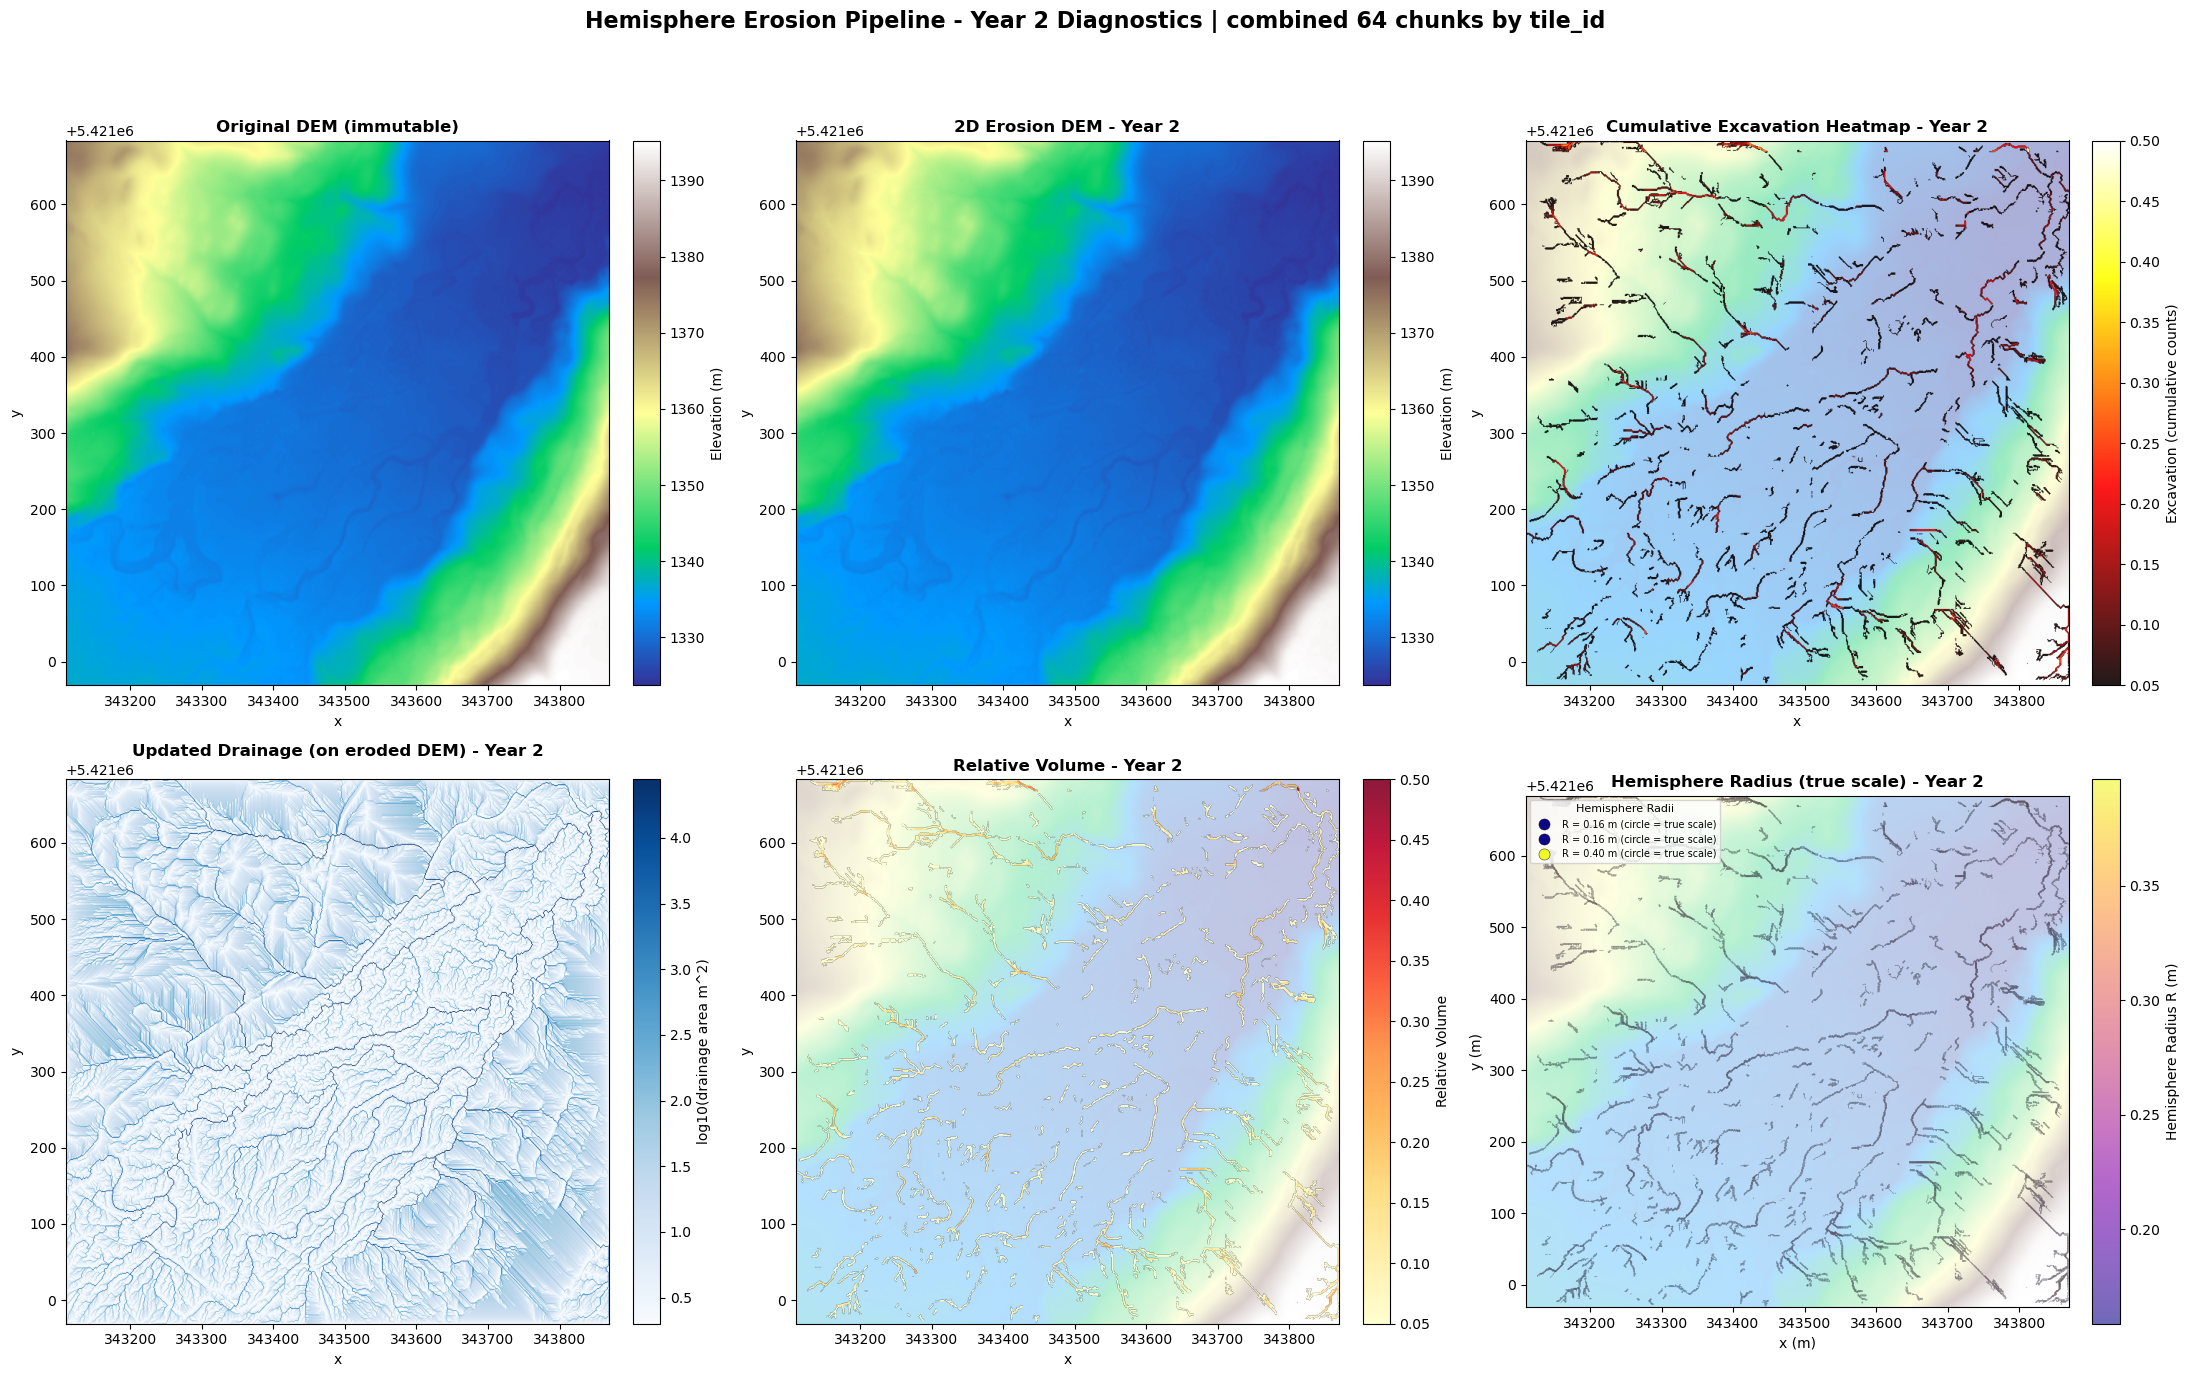

In [13]:
# ========================================================================
# FINAL VISUAL SUMMARY - 6-panel diagnostic figure
# ========================================================================

import importlib
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

import chunk_visualization_utils as _chunk_visualization_utils
import excavation_shapefile_utils as _excavation_shapefile_utils
importlib.reload(_chunk_visualization_utils)
importlib.reload(_excavation_shapefile_utils)
from chunk_visualization_utils import load_final_visualization_inputs
from excavation_shapefile_utils import export_excavation_heatmap_shapefiles, resolve_horizontal_crs

_visual_inputs = load_final_visualization_inputs(
    run_by_chunk=RUN_BY_CHUNK,
    chunk_outputs=globals().get("chunk_outputs"),
    outputs=globals().get("outputs", []),
    preview_df_world=globals().get("preview_df_world"),
    csv_path=CSV_PATH,
    n_years=N_YEARS,
    runs_base_dir=RUNS_BASE_DIR,
    chunk_col=CHUNK_COL if "CHUNK_COL" in globals() else None,
    preview_chunk_id=preview_chunk_id if "preview_chunk_id" in globals() else None,
)

stem = _visual_inputs["stem"]
_run_root = _visual_inputs["run_root"]
_last_year = _visual_inputs["last_year"]
preview_chunk_suffix = _visual_inputs["label_suffix"]
counter_csv = Path(_visual_inputs["counter_path"])
volume_csv = Path(_visual_inputs["volume_path"])
erosion_csv = Path(_visual_inputs["erosion_path"])
updated_csv = Path(_visual_inputs["updated_path"])

if "SITE_SUMMARY_CSV" in globals() and Path(SITE_SUMMARY_CSV).exists():
    _crs_check = resolve_horizontal_crs(SITE_SUMMARY_CSV)
    print("Shapefile CRS check:")
    print(f"  DEM CRS raw value: {_crs_check.raw_value}")
    print(f"  EPSG: {_crs_check.epsg_code}")
    print(f"  WKT source: {_crs_check.source_key}")
    print(f"  Used fallback WKT: {_crs_check.used_fallback_wkt}")

_shapefile_results = export_excavation_heatmap_shapefiles(
    counter_csv,
    site_summary_csv=SITE_SUMMARY_CSV if "SITE_SUMMARY_CSV" in globals() else None,
    out_dir=_run_root,
    geometry="both",
)
print("Excavation shapefiles:")
for _shape_result in _shapefile_results:
    print(f"  {_shape_result.geometry}: {_shape_result.shp_path}")

print(f"Plotting final diagnostics for Year {_last_year}{preview_chunk_suffix}")
print(f"  counter_dem:  {counter_csv}")
print(f"  site_volume:  {volume_csv}")
print(f"  2d_erosion:   {erosion_csv}")
print(f"  updated DEM:  {updated_csv}")

# --- Load data ---
df_counter = _visual_inputs["df_counter"].copy()
df_volume = _visual_inputs["df_volume"].copy()
df_erosion = _visual_inputs["df_erosion"].copy()
df_updated = _visual_inputs["df_updated"].copy()
df_orig = _visual_inputs["df_orig"].copy()

for _df in [df_counter, df_volume, df_erosion, df_updated, df_orig]:
    for c in ["x", "y"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")
    for c in ["elevation", "excavation_m", "drainage_area_m2", "relative_volume", "radius"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")

# Infer grid spacing
_dx = infer_step(df_orig["x"].values)
_dy = infer_step(df_orig["y"].values)
_gs = float(np.nanmin([_dx, _dy]))
if not np.isfinite(_gs) or _gs <= 0:
    _gs = 1.0

def _to_grid(df, col, gs):
    """Pivot a flat df with x,y,col into a 2D array + extent."""
    g, _ = create_grid_FIXED(
        df.dropna(subset=["x", "y", col]),
        grid_spacing=gs, value_cols=(col,),
        agg="mean", return_df_with_indices=True,
    )
    arr = np.asarray(g[col], dtype=float)
    xc, yc = g["x_coords"], g["y_coords"]
    extent = [float(xc.min()), float(xc.max()), float(yc.min()), float(yc.max())]
    return arr, extent

Z_orig, ext = _to_grid(df_orig, "elevation", _gs)
Z_eroded, _ = _to_grid(df_erosion, "elevation", _gs)
exc_grid, _ = _to_grid(df_counter, "excavation_m", _gs)
if "drainage_area_m2" in df_updated.columns:
    da_grid, _ = _to_grid(df_updated, "drainage_area_m2", _gs)
else:
    da_grid = np.full_like(Z_orig, np.nan)
rv_grid, _ = _to_grid(df_volume, "relative_volume", _gs)

# --- Build the 6-panel figure ---
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle(
    f"Hemisphere Erosion Pipeline - Year {_last_year} Diagnostics{preview_chunk_suffix}",
    fontsize=16, fontweight="bold", y=0.98,
)

vmin_elev = np.nanmin([np.nanmin(Z_orig), np.nanmin(Z_eroded)])
vmax_elev = np.nanmax([np.nanmax(Z_orig), np.nanmax(Z_eroded)])

# --- Panel 1: Original DEM ---
ax = axes[0, 0]
im = ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain",
               aspect="auto", vmin=vmin_elev, vmax=vmax_elev)
ax.set_title("Original DEM (immutable)", fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04)

# --- Panel 2: 2D Erosion DEM ---
ax = axes[0, 1]
im = ax.imshow(Z_eroded, origin="lower", extent=ext, cmap="terrain",
               aspect="auto", vmin=vmin_elev, vmax=vmax_elev)
ax.set_title(f"2D Erosion DEM - Year {_last_year}", fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04)

# --- Panel 3: Excavation Heatmap ---
ax = axes[0, 2]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.4)
exc_masked = np.ma.masked_where(exc_grid <= 0, exc_grid)
im = ax.imshow(exc_masked, origin="lower", extent=ext, cmap="hot",
               aspect="auto", alpha=0.9)
ax.set_title(f"Cumulative Excavation Heatmap - Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Excavation (cumulative counts)", fraction=0.046, pad=0.04)

# --- Panel 4: Updated Drainage ---
ax = axes[1, 0]
cell_area = _gs * _gs
log_da = np.log10(da_grid + cell_area)
vmin_da, vmax_da = np.nanpercentile(log_da, [5, 99.5])
im = ax.imshow(log_da, origin="lower", extent=ext, cmap="Blues",
               aspect="auto", vmin=vmin_da, vmax=vmax_da)
ax.set_title(f"Updated Drainage (on eroded DEM) - Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="log10(drainage area m^2)", fraction=0.046, pad=0.04)

# --- Panel 5: Relative Volume ---
ax = axes[1, 1]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.3)
rv_masked = np.ma.masked_where(rv_grid <= 0, rv_grid)
im = ax.imshow(rv_masked, origin="lower", extent=ext, cmap="YlOrRd",
               aspect="auto", alpha=0.9)
ax.set_title(f"Relative Volume - Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Relative Volume", fraction=0.046, pad=0.04)

# --- Panel 6: Radius Scatter Plot (TRUE DATA-SCALE CIRCLES) ---
ax = axes[1, 2]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.3)
df_r = df_volume[df_volume["radius"] > 0].copy()

if len(df_r) > 0:
    from matplotlib.patches import Circle
    from matplotlib.collections import PatchCollection
    import matplotlib.cm as cm

    x_pts = df_r["x"].values
    y_pts = df_r["y"].values
    r_pts = df_r["radius"].values

    sort_idx = np.argsort(-r_pts)
    x_pts = x_pts[sort_idx]
    y_pts = y_pts[sort_idx]
    r_pts = r_pts[sort_idx]

    patches = []
    for k in range(len(x_pts)):
        patches.append(Circle((x_pts[k], y_pts[k]), r_pts[k]))

    cmap = cm.get_cmap("plasma")
    norm = plt.Normalize(vmin=r_pts.min(), vmax=r_pts.max())

    pc = PatchCollection(patches, cmap=cmap, norm=norm,
                         alpha=0.6, edgecolors="k", linewidths=0.3)
    pc.set_array(r_pts)
    ax.add_collection(pc)
    plt.colorbar(pc, ax=ax, label="Hemisphere Radius R (m)",
                 fraction=0.046, pad=0.04)

    for rv in [r_pts.min(), np.median(r_pts), r_pts.max()]:
        ax.plot([], [], 'o', color=cmap(norm(rv)), markersize=8,
                markeredgecolor="k", markeredgewidth=0.3,
                label=f"R = {rv:.2f} m (circle = true scale)")
    ax.legend(loc="upper left", fontsize=7, title="Hemisphere Radii",
              title_fontsize=8, framealpha=0.8)
else:
    ax.text(0.5, 0.5, "No excavation cells", ha="center", va="center",
            transform=ax.transAxes, fontsize=14, color="red")

ax.set_title(f"Hemisphere Radius (true scale) - Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_xlim(ext[0], ext[1])
ax.set_ylim(ext[2], ext[3])
ax.set_aspect("equal")

plt.tight_layout(rect=[0, 0, 1, 0.95])
diagnostics_path = _run_root / f"{stem}_year{_last_year:02d}_final_diagnostics.png"
plt.savefig(diagnostics_path, dpi=200, bbox_inches="tight")
print(f"Saved final diagnostics figure: {diagnostics_path}")
plt.show()


## Cell 14 - Erosion Difference Map + Cross-Section

Shows **what changed**: Original DEM minus 2D Erosion DEM.
Includes erosion contours and a cross-section through the deepest carving.

C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\1187078328.py:61: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_7028\1187078328.py:63: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.savefig(diff_path, dpi=200, bbox_inches="tight")


Saved erosion difference figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_year02_erosion_difference.png


C:\Users\jordan.kennedy\anaconda3\envs\mesa-geo-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


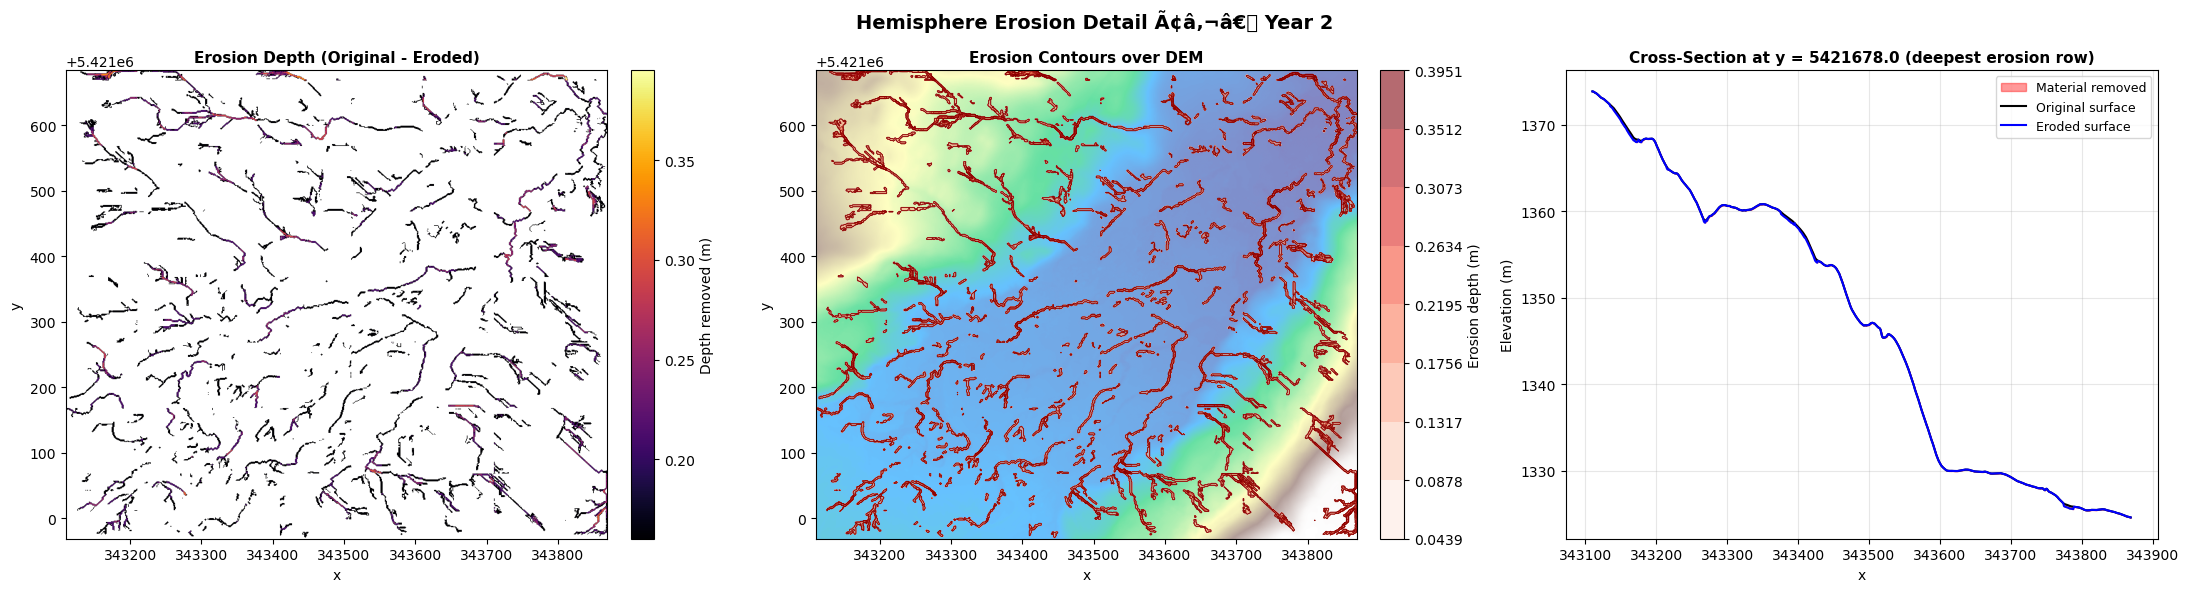


--- Erosion Summary (Year 2) ---
  Max erosion depth:     0.395 m
  Mean erosion (active): 0.181 m
  Cells eroded:          37,861
  Total volume removed:  6858.5 m^3
  Active radius cells:   37,861
  R range:               0.159 - 0.397 m


In [14]:
# ========================================================================
# EROSION DIFFERENCE MAP + CROSS-SECTION
# ========================================================================

diff = Z_orig - Z_eroded  # positive = material removed
diff_masked = np.ma.masked_where(diff <= 0, diff)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    f"Hemisphere Erosion Detail Ã¢â‚¬â€ Year {_last_year}",
    fontsize=14, fontweight="bold",
)

# Panel 1: Erosion depth map
ax = axes[0]
im = ax.imshow(diff_masked, origin="lower", extent=ext, cmap="inferno",
               aspect="auto")
ax.set_title("Erosion Depth (Original - Eroded)", fontsize=11, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Depth removed (m)", fraction=0.046, pad=0.04)

# Panel 2: Erosion contours over DEM
ax = axes[1]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.6)
ny_d, nx_d = diff.shape
x_lin = np.linspace(ext[0], ext[1], nx_d)
y_lin = np.linspace(ext[2], ext[3], ny_d)
XX, YY = np.meshgrid(x_lin, y_lin)
diff_clean = np.where(np.isfinite(diff), diff, 0.0)
if diff_clean.max() > 0:
    levels = np.linspace(0, float(diff_clean.max()), 10)
    levels = levels[levels > 0]
    if len(levels) > 1:
        cs = ax.contourf(XX, YY, diff_clean, levels=levels, cmap="Reds", alpha=0.6)
        plt.colorbar(cs, ax=ax, label="Erosion depth (m)", fraction=0.046, pad=0.04)
        ax.contour(XX, YY, diff_clean, levels=levels, colors="darkred",
                   linewidths=0.5, alpha=0.7)
ax.set_title("Erosion Contours over DEM", fontsize=11, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")

# Panel 3: Cross-section through deepest point
ax = axes[2]
row_sums = np.nansum(diff_clean, axis=1)
deepest_row = int(np.argmax(row_sums))
y_val = ext[2] + deepest_row * _gs
profile_orig = Z_orig[deepest_row, :]
profile_eroded = Z_eroded[deepest_row, :]
x_profile = np.linspace(ext[0], ext[1], len(profile_orig))

ax.fill_between(x_profile, profile_eroded, profile_orig,
                alpha=0.4, color="red", label="Material removed")
ax.plot(x_profile, profile_orig, 'k-', linewidth=1.5, label="Original surface")
ax.plot(x_profile, profile_eroded, 'b-', linewidth=1.5, label="Eroded surface")
ax.set_title(f"Cross-Section at y = {y_val:.1f} (deepest erosion row)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("Elevation (m)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
diff_path = _run_root / f"{stem}_year{_last_year:02d}_erosion_difference.png"
plt.savefig(diff_path, dpi=200, bbox_inches="tight")
print(f"Saved erosion difference figure: {diff_path}")
plt.show()

# Print summary stats
print(f"\n--- Erosion Summary (Year {_last_year}) ---")
print(f"  Max erosion depth:     {float(np.nanmax(diff)):.3f} m")
if (diff > 0).any():
    print(f"  Mean erosion (active): {float(np.nanmean(diff[diff > 0])):.3f} m")
else:
    print(f"  No erosion detected")
print(f"  Cells eroded:          {int((diff > 0).sum()):,}")
print(f"  Total volume removed:  {float(np.nansum(diff) * _gs * _gs):.1f} m^3")
n_r = int((df_volume['radius'] > 0).sum())
print(f"  Active radius cells:   {n_r:,}")
if n_r > 0:
    print(f"  R range:               {float(df_volume['radius'][df_volume['radius']>0].min()):.3f} - {float(df_volume['radius'].max()):.3f} m")

## Cell 15 - Canal Prediction on Real Landscapes

Reconstructs an RGB basemap from the NAIP red, green, and blue bands, then overlays predicted erosion depth so likely canal locations can be read directly against the real landscape.


Saved real-landscape canal prediction figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_year02_canal_prediction_real_landscape.png
Max predicted erosion depth: 0.395 m


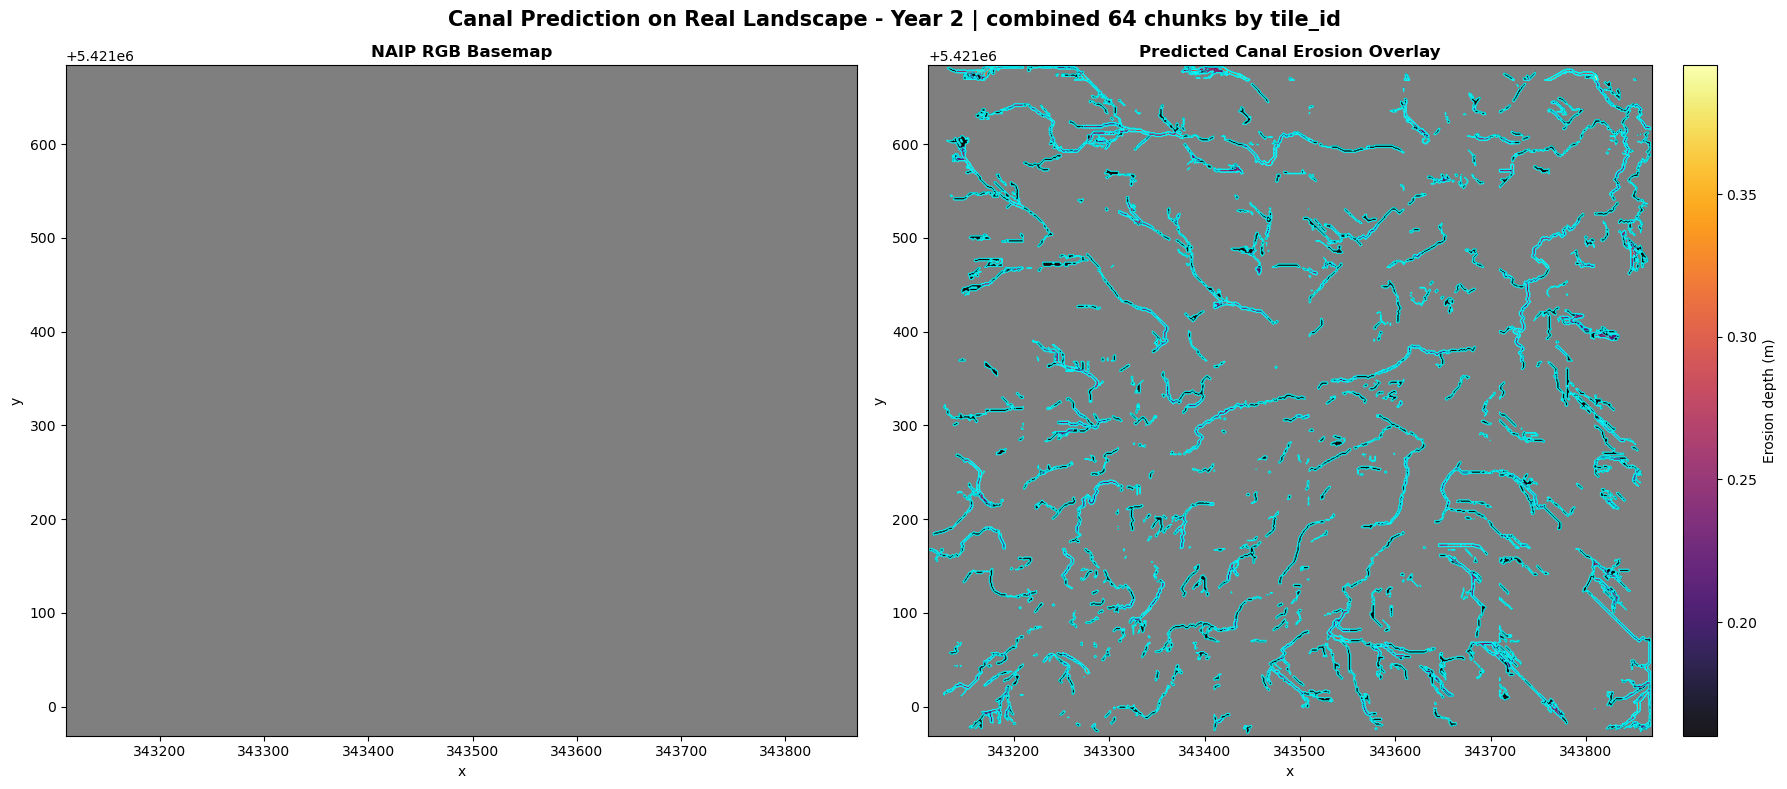

In [15]:
# ========================================================================
# CANAL PREDICTION ON REAL LANDSCAPES (RGB + erosion overlay)
# ========================================================================

import importlib
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

if "_visual_inputs" not in globals():
    import chunk_visualization_utils as _chunk_visualization_utils
    importlib.reload(_chunk_visualization_utils)
    from chunk_visualization_utils import load_final_visualization_inputs

    _visual_inputs = load_final_visualization_inputs(
        run_by_chunk=RUN_BY_CHUNK,
        chunk_outputs=globals().get("chunk_outputs"),
        outputs=globals().get("outputs", []),
        preview_df_world=globals().get("preview_df_world"),
        csv_path=CSV_PATH,
        n_years=N_YEARS,
        runs_base_dir=RUNS_BASE_DIR,
        chunk_col=CHUNK_COL if "CHUNK_COL" in globals() else None,
        preview_chunk_id=preview_chunk_id if "preview_chunk_id" in globals() else None,
    )

stem = _visual_inputs["stem"]
_run_root = _visual_inputs["run_root"]
_last_year = _visual_inputs["last_year"]
preview_chunk_suffix = _visual_inputs["label_suffix"]

df_orig_rgb = _visual_inputs["df_orig"].copy()
df_erosion_rgb = _visual_inputs["df_erosion"].copy()
required_rgb = ["x", "y", "elevation", "naip_R", "naip_G", "naip_B"]
missing_rgb = [c for c in required_rgb if c not in df_orig_rgb.columns]
if missing_rgb:
    raise ValueError(f"Missing NAIP/RGB columns required for overlay: {missing_rgb}")
for _df in [df_orig_rgb, df_erosion_rgb]:
    for c in ["x", "y", "elevation"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")
for c in ["naip_R", "naip_G", "naip_B"]:
    df_orig_rgb[c] = pd.to_numeric(df_orig_rgb[c], errors="coerce")
_dx_rgb = infer_step(df_orig_rgb["x"].values)
_dy_rgb = infer_step(df_orig_rgb["y"].values)
_gs_rgb = float(np.nanmin([_dx_rgb, _dy_rgb]))
if not np.isfinite(_gs_rgb) or _gs_rgb <= 0:
    _gs_rgb = 1.0

def _grid_one(df, col, gs):
    g, _ = create_grid_FIXED(
        df.dropna(subset=["x", "y", col]),
        grid_spacing=gs, value_cols=(col,),
        agg="mean", return_df_with_indices=True,
    )
    arr = np.asarray(g[col], dtype=float)
    xc, yc = g["x_coords"], g["y_coords"]
    extent = [float(np.min(xc)), float(np.max(xc)), float(np.min(yc)), float(np.max(yc))]
    return arr, extent

R, ext_rgb = _grid_one(df_orig_rgb, "naip_R", _gs_rgb)
G, _ = _grid_one(df_orig_rgb, "naip_G", _gs_rgb)
B, _ = _grid_one(df_orig_rgb, "naip_B", _gs_rgb)
Z_orig_rgb, _ = _grid_one(df_orig_rgb, "elevation", _gs_rgb)
Z_eroded_rgb, _ = _grid_one(df_erosion_rgb, "elevation", _gs_rgb)

def _normalize_band(arr):
    arr = np.asarray(arr, dtype=float)
    finite = np.isfinite(arr)
    out = np.zeros_like(arr, dtype=float)
    if not finite.any():
        return out
    lo, hi = np.nanpercentile(arr[finite], [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(arr[finite]))
        hi = float(np.nanmax(arr[finite]))
    if not np.isfinite(hi) or hi <= lo:
        out[finite] = 0.5
        return out
    out[finite] = np.clip((arr[finite] - lo) / (hi - lo), 0, 1)
    return out

rgb_img = np.dstack([_normalize_band(R), _normalize_band(G), _normalize_band(B)])
erosion_depth = np.maximum(Z_orig_rgb - Z_eroded_rgb, 0.0)
erosion_masked = np.ma.masked_where(~np.isfinite(erosion_depth) | (erosion_depth <= 0), erosion_depth)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    f"Canal Prediction on Real Landscape - Year {_last_year}{preview_chunk_suffix}",
    fontsize=15, fontweight="bold"
)

ax = axes[0]
ax.imshow(rgb_img, origin="lower", extent=ext_rgb, aspect="auto")
ax.set_title("NAIP RGB Basemap", fontsize=12, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax = axes[1]
ax.imshow(rgb_img, origin="lower", extent=ext_rgb, aspect="auto")
im = ax.imshow(
    erosion_masked, origin="lower", extent=ext_rgb, aspect="auto",
    cmap="inferno", alpha=0.9
)
ax.set_title("Predicted Canal Erosion Overlay", fontsize=12, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Erosion depth (m)", fraction=0.046, pad=0.04)
if np.isfinite(erosion_depth).any() and float(np.nanmax(erosion_depth)) > 0:
    levels = np.linspace(float(np.nanmax(erosion_depth)) * 0.2, float(np.nanmax(erosion_depth)), 6)
    levels = np.unique(levels[levels > 0])
    if len(levels) > 0:
        ax.contour(
            erosion_depth, levels=levels, origin="lower", extent=ext_rgb,
            colors="cyan", linewidths=0.6, alpha=0.8
        )

plt.tight_layout()
real_landscape_path = _run_root / f"{stem}_year{_last_year:02d}_canal_prediction_real_landscape.png"
plt.savefig(real_landscape_path, dpi=200, bbox_inches="tight")
print(f"Saved real-landscape canal prediction figure: {real_landscape_path}")
print(f"Max predicted erosion depth: {float(np.nanmax(erosion_depth)):.3f} m")
plt.show()


In [16]:
import importlib
from pathlib import Path
import sys

# If excavation_shapefile_utils.py is in the same folder as the notebook,
# this should work directly. If not, add its folder to sys.path.
# Example:
# sys.path.append("/content/drive/MyDrive/YOUR_FOLDER_HERE")

import excavation_shapefile_utils as _excavation_shapefile_utils
importlib.reload(_excavation_shapefile_utils)
from excavation_shapefile_utils import export_excavation_heatmap_shapefiles, zip_shapefile_results

# 1. Point this to the folder where your Mesa run outputs were saved
RUN_DIR = Path(CSV_DIR)

# 2. Find all counter files
counter_csvs = sorted(RUN_DIR.rglob("*_counter_dem.csv"))

print("Found counter CSVs:")
for i, p in enumerate(counter_csvs):
    print(i, p)

# 3. Choose the final year, usually the last one
counter_csv = counter_csvs[-1]
print("\nExporting:", counter_csv)

# 4. Export shapefiles
out_dir = counter_csv.parent / "shapefiles"

results = export_excavation_heatmap_shapefiles(
    counter_csv,
    out_dir=out_dir,
    geometry="both",   # options: "polygon", "point", or "both"
)

for result in results:
    print(f"{result.geometry}: {result.record_count} features")
    print("  shp:", result.shp_path)
    print("  dbf:", result.dbf_path)
    print("  shx:", result.shx_path)
    print("  prj:", result.prj_path)
    print("  cpg:", result.cpg_path)

# 5. Zip only the shapefile sidecars, skipping transient GIS lock files
zip_path = zip_shapefile_results(results, archive_path=out_dir.with_suffix('.zip'), root_dir=out_dir)
print("\nZipped shapefiles here:")
print(zip_path)

Found counter CSVs:
0 C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_year02_counter_dem.csv

Exporting: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_year02_counter_dem.csv
polygon: 37861 features
  shp: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\shapefiles\RumneyRanch_slopes_all_chunks_year02_excavation_heatmap_cells.shp
  dbf: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\shapefiles\RumneyRanch_slopes_all_chunks_year02_excavation_heatmap_cells.dbf
  shx: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\shapefiles\RumneyRanch_slopes_all_chunks_year02_excavation_heatmap_cells.shx
  prj: C:\Users\jordan.kennedy\Documents\Project\MultiAgent

In [17]:
import importlib
from pathlib import Path

import excavation_shapefile_utils as _excavation_shapefile_utils
importlib.reload(_excavation_shapefile_utils)
from excavation_shapefile_utils import export_excavation_heatmap_shapefiles, zip_shapefile_results

# Option A: if you ran the diagnostic/visualization cells,
# the notebook already knows the final site_volume path
try:
    volume_csv = Path(_visual_inputs["volume_path"])
except NameError:
    # Option B: manually point to your run folder
    RUN_DIR = Path(CSV_DIR)
    volume_csvs = sorted(RUN_DIR.rglob("*_site_volume_year*.csv"))
    volume_csv = volume_csvs[-1]  # final year

print("Exporting hemisphere radius from:")
print(volume_csv)

out_dir = volume_csv.parent / "radius_shapefiles"

results = export_excavation_heatmap_shapefiles(
    volume_csv,
    out_dir=out_dir,
    out_stem=f"{volume_csv.stem}_hemisphere_radius",
    geometry="both",        # "polygon", "point", or "both"
    value_col="radius",     # <-- this is the key change
    tile_col=None,          # site_volume usually only has x, y, relative_volume, radius
    positive_only=True,
)

for result in results:
    print(f"{result.geometry}: {result.record_count} features")
    print("  shp:", result.shp_path)
    print("  dbf:", result.dbf_path)
    print("  shx:", result.shx_path)
    print("  prj:", result.prj_path)
    print("  cpg:", result.cpg_path)

zip_path = zip_shapefile_results(results, archive_path=out_dir.with_suffix('.zip'), root_dir=out_dir)
print("\nZipped shapefiles here:")
print(zip_path)

Exporting hemisphere radius from:
C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\RumneyRanch_slopes_all_chunks_site_volume_year02.csv
polygon: 37861 features
  shp: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\radius_shapefiles\RumneyRanch_slopes_all_chunks_site_volume_year02_hemisphere_radius_cells.shp
  dbf: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\radius_shapefiles\RumneyRanch_slopes_all_chunks_site_volume_year02_hemisphere_radius_cells.dbf
  shx: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\radius_shapefiles\RumneyRanch_slopes_all_chunks_site_volume_year02_hemisphere_radius_cells.shx
  prj: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\RumneyRanch\runs\combined_final\radius_shapefiles\RumneyRanch_slopes_all_chunks_sit